In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm                 # barra de progeso
from scipy.stats import norm 

import matplotlib as mpl
mpl.rcParams["axes.labelsize"] = 13   # tamaño por defecto de todos los ejes

In [3]:
import tables as tb
file = "merged.kdst"
pd.DataFrame(tb.open_file(file).root.config.detsim[:]).head(30).iloc[10].value

b"{'ws': 3.9200000000000004e-05, 'wi': 2.24e-05, 'fano_factor': 0.15, 'conde_policarpo_factor': 0.0261, 'drift_velocity': 0.00087, 'el_drift_velocity': 0.0051600000000000005, 'transverse_diffusion': 0.6356178096938442, 'longitudinal_diffusion': 0.18341210428976598, 'el_gain': 754, 'lifetime': 50000000"

Aquí se puede observar que en la Fast Simulation 4 bar es $\tau = 5\cdot 10^4\ \mu s$

## Importamos las simulaciones

- Simulación 1 => Full Sim 4 bar

In [8]:
frames_sim1 = []
for ifile in range(0, 999):
    file = f"Simulacion2/NEXT100_Kr83m_Full_dorothea_{ifile}.h5"
    if os.path.exists(file):
        # if ifile%100==0: print(f"Abriendo archivo {ifile}")
        dst = pd.DataFrame(tb.open_file(file).root.DST.Events[:]) 
        frames_sim1.append(dst) 
sim1 = pd.concat(frames_sim1, ignore_index=True)
sim1 = sim1[sim1.R >= 0] # filtramos  porque algunas variables se procesan mal y ponen radio negativo

- Simulación 2 => Fast Sim 4 bar

In [10]:
df = pd.read_hdf("merged.kdst", "DST/Events")
frames_sim2=[]
frames_sim2.append(df)
sim2 = pd.concat(frames_sim2)
sim2 = sim2[sim2.R >= 0] # filtramos

- Simulación 3 => Fast Sim 5 bar

In [12]:
frames_sim3 = []
for ifile in range(0, 1001):  
    file = f'Dorothea/next100_kr83m_dorothea_{ifile}.h5' #Nombres de los archivos
    if os.path.exists(file):
        # if ifile%100==0: print(f"Abriendo archivo {ifile}")
        dst = pd.DataFrame(tb.open_file(file).root.DST.Events[:]) 
        frames_sim3.append(dst) # Guarda cada uno de los DataFrames en una lista
sim3 = pd.concat(frames_sim3, ignore_index=True) # Hace un nuevo DataFrame juntando los individuales
sim3 = sim3[sim3.R >= 0] # filtramos

In [13]:
# Establecemos los títulos para el resto del programa
titulos = ["FULL SIMULATION 4 BAR", "FAST SIMULATION 4 BAR", "FAST SIMULATION 5 BAR",]

# Densidad de estados

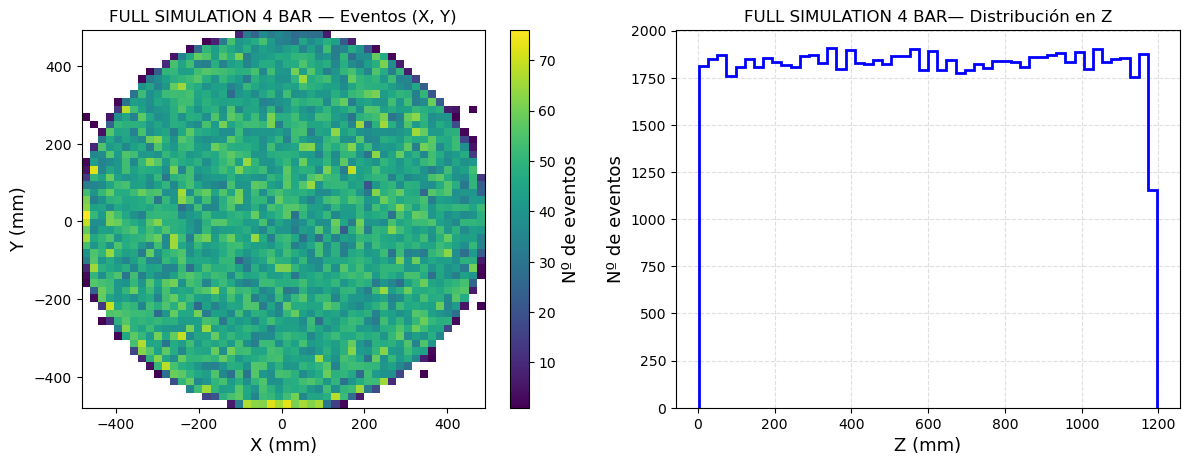

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma X vs Y
h = ax[0].hist2d(sim1["X"], sim1["Y"], bins=50, cmap="viridis", cmin = 1)
ax[0].set_title(f"{titulos[0]} — Eventos (X, Y)")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(h[3], ax=ax[0], label="Nº de eventos")

# Histograma Z
ax[1].hist(sim1['Z'], bins=50, histtype="step", edgecolor="blue", linewidth = 2)
ax[1].set_title(f"{titulos[0]}— Distribución en Z")
ax[1].set_xlabel("Z (mm)")
ax[1].set_ylabel("Nº de eventos")
ax[1].grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(top=0.88)

plt.savefig("graficas/densidad_eventos_1.png")

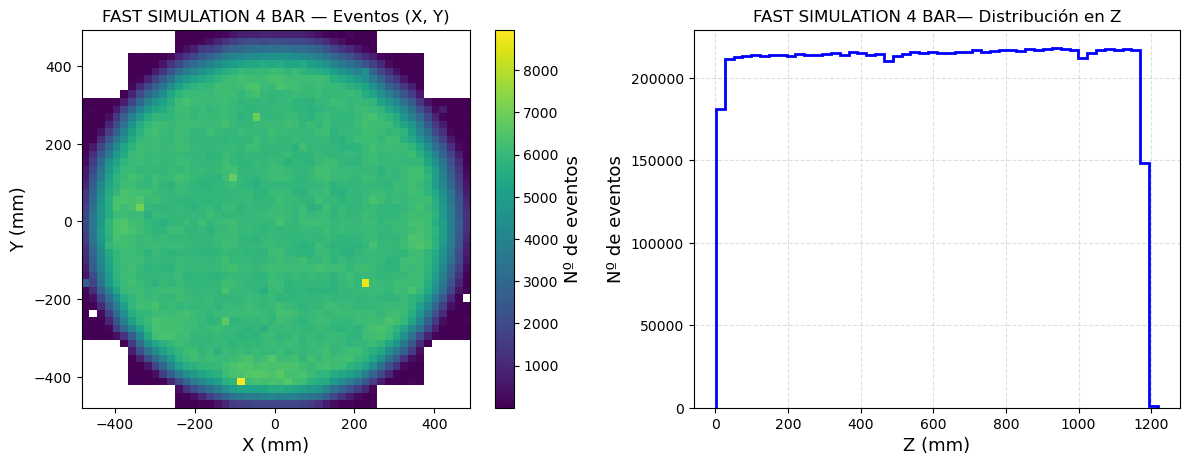

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma X vs Y
h = ax[0].hist2d(sim2["X"], sim2["Y"], bins=50, cmap="viridis", cmin = 1)
ax[0].set_title(f"{titulos[1]} — Eventos (X, Y)")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(h[3], ax=ax[0], label="Nº de eventos")

# Histograma Z
ax[1].hist(sim2['Z'], bins=50, histtype="step", edgecolor="blue", linewidth = 2)
ax[1].set_title(f"{titulos[1]}— Distribución en Z")
ax[1].set_xlabel("Z (mm)")
ax[1].set_ylabel("Nº de eventos")
ax[1].grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(top=0.88)

plt.savefig("graficas/densidad_eventos_2.png")

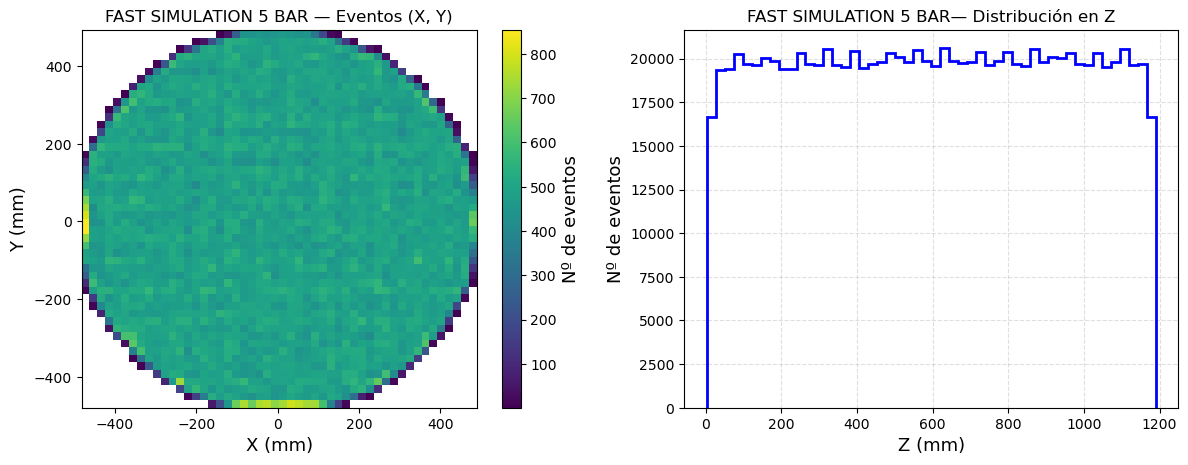

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma X vs Y
h = ax[0].hist2d(sim3["X"], sim3["Y"], bins=50, cmap="viridis", cmin = 1)
ax[0].set_title(f"{titulos[2]} — Eventos (X, Y)")
ax[0].set_xlabel("X (mm)")
ax[0].set_ylabel("Y (mm)")
fig.colorbar(h[3], ax=ax[0], label="Nº de eventos")

# Histograma Z
ax[1].hist(sim3['Z'], bins=50, histtype="step", edgecolor="blue", linewidth = 2)
ax[1].set_title(f"{titulos[2]}— Distribución en Z")
ax[1].set_xlabel("Z (mm)")
ax[1].set_ylabel("Nº de eventos")
ax[1].grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.subplots_adjust(top=0.88)

plt.savefig("graficas/densidad_eventos_3.png")

# S1e frente a Z

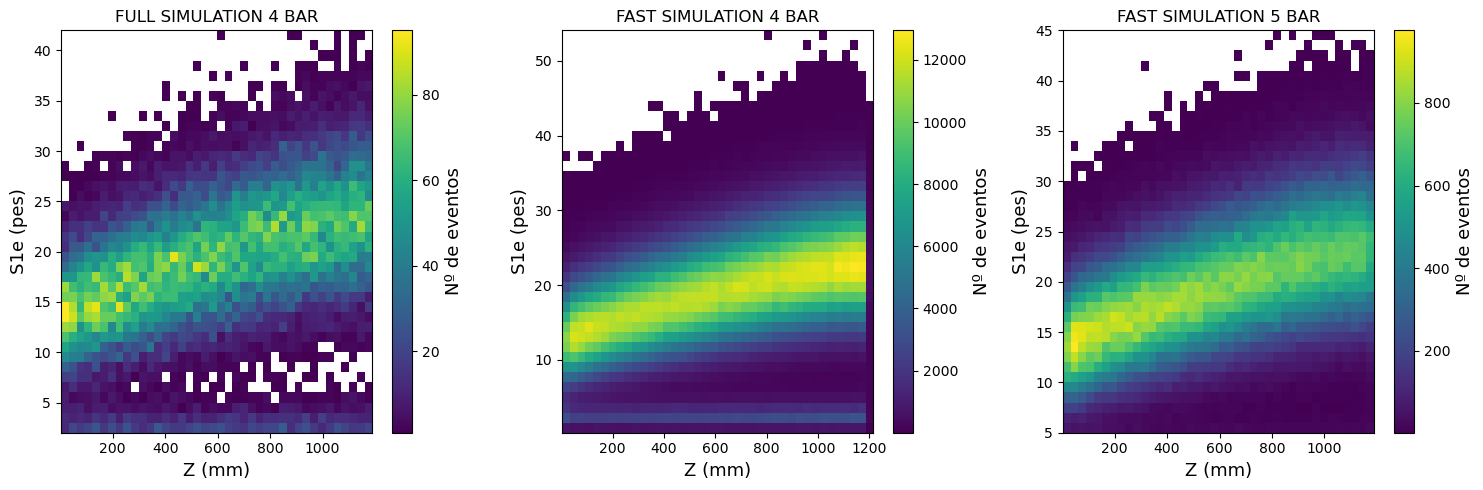

In [19]:
# Filtramos a R < 300 mm
sim1_300 = sim1[(sim1.R <= 300)]
sim2_300 = sim2[(sim2.R <= 300)]
sim3_300 = sim3[(sim3.R <= 300)]

sims = [sim1_300, sim2_300, sim3_300]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

h1 = axes[0].hist2d(sim1_300["Z"], sim1_300["S1e"], bins = 40, cmin = 1)
cbar1 = fig.colorbar(h1[3], ax = axes[0])  
axes[0].set_xlabel("Z (mm)")
axes[0].set_ylabel("S1e (pes)")
axes[0].set_title(titulos[0])
cbar1.set_label("Nº de eventos")

h2 = axes[1].hist2d(sim2_300["Z"], sim2_300["S1e"], bins = 40, cmin = 1)
cbar2 = fig.colorbar(h2[3], ax = axes[1]) 
axes[1].set_xlabel("Z (mm)")
axes[1].set_ylabel("S1e (pes)")
axes[1].set_title(titulos[1])
cbar2.set_label("Nº de eventos")

h3 = axes[2].hist2d(sim3_300["Z"], sim3_300["S1e"], bins = 40, cmin = 1)
cbar3 = fig.colorbar(h3[3], ax = axes[2])  
axes[2].set_xlabel("Z (mm)")
axes[2].set_ylabel("S1e (pes)")
axes[2].set_title(titulos[2])
cbar3.set_label("Nº de eventos")

plt.tight_layout()
plt.savefig("graficas/S1e vs Z R300mm")

In [20]:
# Función profile
def plot_profile(ax, x, y, bins=25, color="red", marker="*", label = None):
    
    # Crear bordes y centros de los bins
    bin_edges = np.linspace(x.min(), x.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Arrays de medias y errores
    mean = np.full_like(bin_centers, np.nan, dtype=float) # creamos array del tamaño de bin_centers
    std_err = np.full_like(bin_centers, np.nan, dtype=float)

    for i in range(len(bin_centers)):
        mask = (x >= bin_edges[i]) & (x < bin_edges[i + 1]) # filtramos valores dentro de cada bin
        valores = y[mask] # valores que cuadren dentro del bin
        N = len(valores)
        if N > 0:
            mean[i] = np.mean(valores)
            std_err[i] = np.std(valores, ddof=1) / np.sqrt(N)

    ax.errorbar(bin_centers, mean, yerr = std_err, fmt = "*", color = color, capsize = 3, markersize = 4)

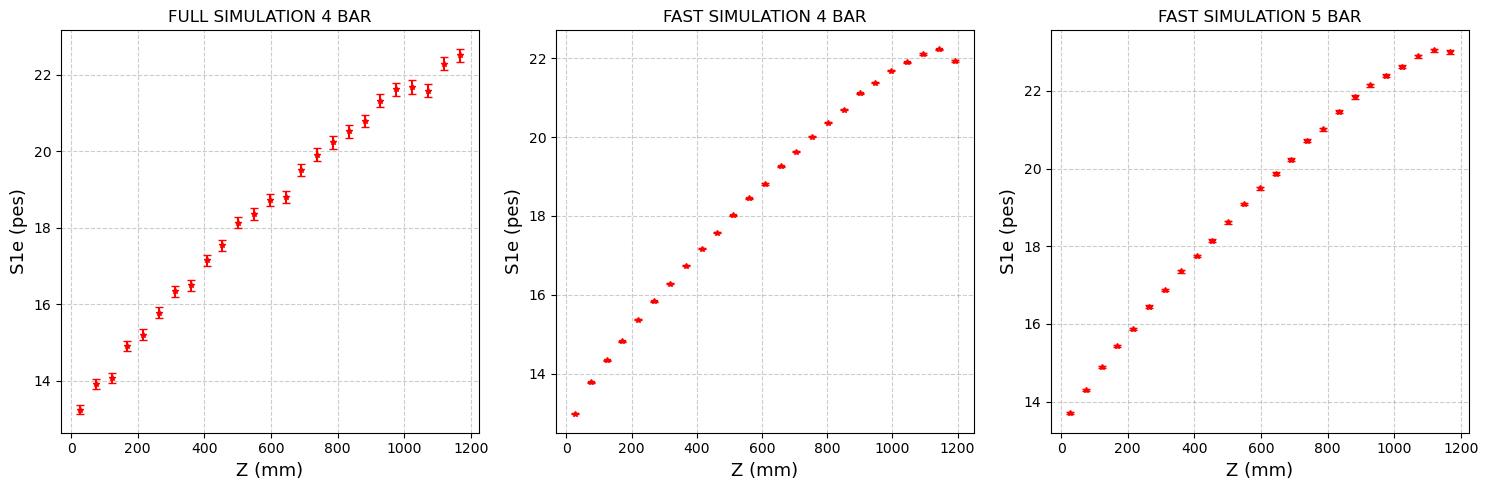

In [21]:
simulaciones = [sim1, sim2, sim3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for sim, ax, titulo in zip(sims, axes, titulos): # recorremos las sims, figuras y axes a la vez
    plot_profile(ax, sim["Z"], sim["S1e"])
    ax.set_xlabel("Z (mm)")
    ax.set_ylabel("S1e (pes)")
    ax.set_title(titulo)
    ax.grid(True, linestyle = "--", color = "gray", alpha = 0.4)

plt.tight_layout()

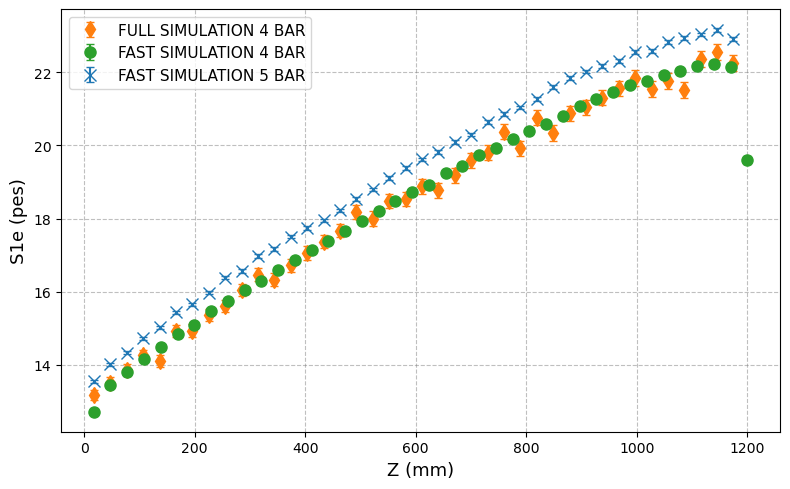

In [22]:
# Redefinimos el profile para ponerlo en la misma gráfica con distintos colores y marcadores
def plot_profile(ax, x, y, bins, color="red", marker="*", label=None):
    bin_edges = np.linspace(x.min(), x.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mean = np.full_like(bin_centers, np.nan, dtype=float)
    std_err = np.full_like(bin_centers, np.nan, dtype=float)
    for i in range(len(bin_centers)):
        mask = (x >= bin_edges[i]) & (x < bin_edges[i + 1])
        valores = y[mask]
        N = len(valores)
        if N > 0:
            mean[i] = np.mean(valores)
            std_err[i] = np.std(valores, ddof=1) / np.sqrt(N)

    # Plot con barras de error
    ax.errorbar(bin_centers, mean, yerr = std_err, fmt = marker, color = color, capsize = 3, markersize = 8, label = label)

n_bins  = 40
markers = ["d", "o", "x"]
colors  = ["tab:orange", "tab:green","tab:blue"]

fig, ax = plt.subplots(figsize=(8, 5))
sim_list = [sim1_300, sim2_300, sim3_300]

# Dibujar cada simulación usando plot_profile
for sim, m, lab, col in zip(sim_list, markers, titulos, colors):
    plot_profile(ax, x = sim["Z"], y = sim["S1e"], bins = n_bins, color = col, marker = m, label = lab)

ax.set_xlabel("Z (mm)")
ax.set_ylabel("S1e (pes)")
ax.grid(True, which = "both", linestyle = "--", color = "gray", alpha = 0.5)
ax.legend(loc = "best", fontsize = 11)
plt.tight_layout()

Se observa que en en la tercera simulación, Fast Simulation 4 bars la componente "Z" es ligeramente mayoir que en las otras imulaciones, además que dicho intervalo tiene muy pocos eventos por lo que procedemos eliminarlo del "profile".

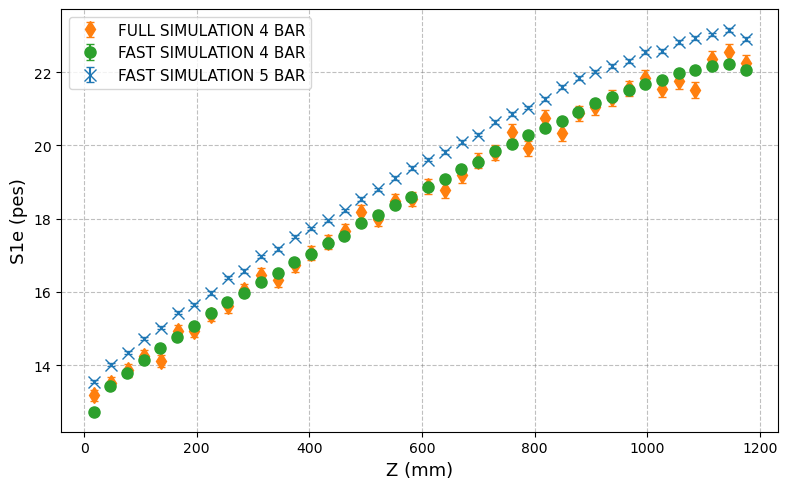

In [24]:
Zmax = sim1_300["Z"].max()
sim2_300.loc[:, "Z"] = np.minimum(sim2_300["Z"], Zmax)

fig, ax = plt.subplots(figsize=(8, 5))
labels  = titulos

for sim, m, lab, col in zip(sim_list, markers, labels, colors):
    plot_profile(ax, x = sim["Z"], y = sim["S1e"], bins = n_bins, color = col, marker = m, label = lab )

ax.set_xlabel("Z (mm)")
ax.set_ylabel("S1e (pes)")
ax.grid(True, which="both", linestyle="--", color="gray", alpha=0.5)
ax.legend(loc="best", fontsize=11)
plt.tight_layout()
fig.savefig("graficas/profile S1e vs Z")

# S2e frente a DT

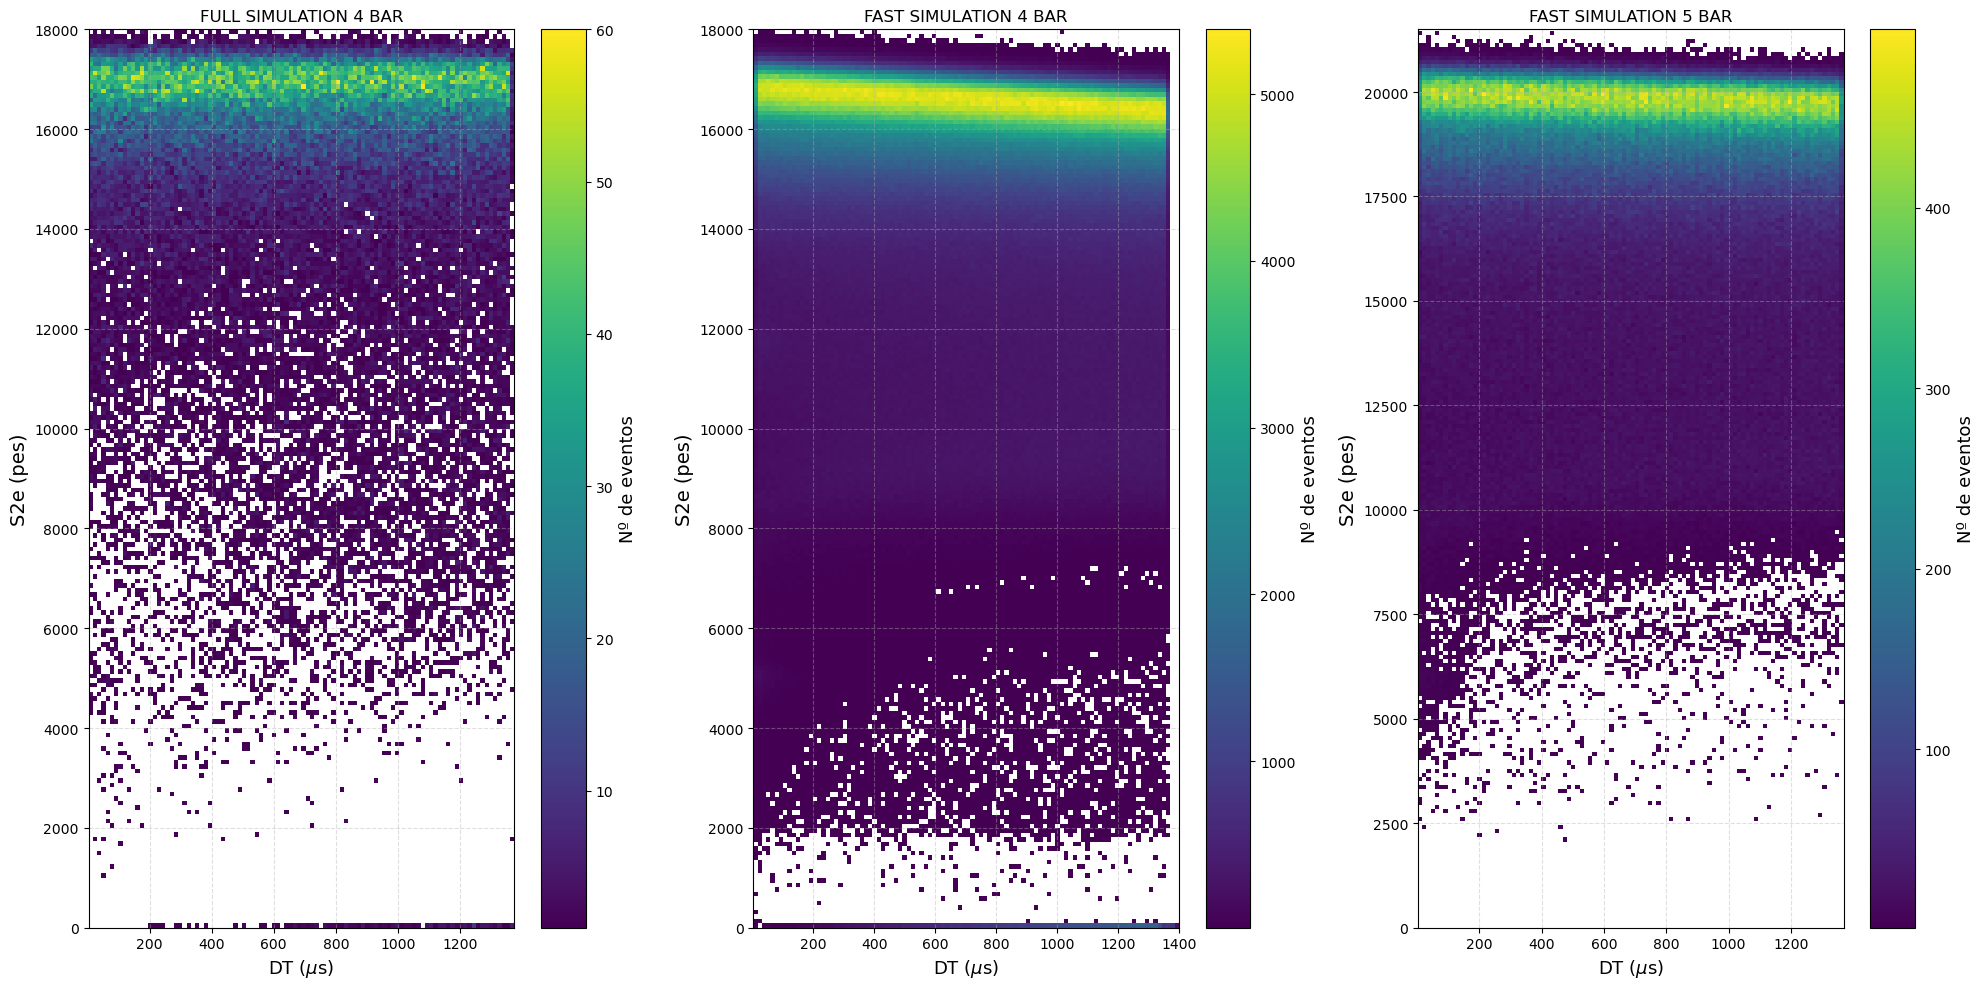

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

datos = [(sim1["DT"], sim1["S2e"], (0, 18000)),
         (sim2["DT"], sim2["S2e"], (0, 18000)),
         (sim3["DT"], sim3["S2e"], (0, 21500))]

for i, ax in enumerate(axes):
    DT, S2e, ylim = datos[i]
    h = ax.hist2d(DT, S2e, bins = [100, 200], cmin = 1)
    ax.set_xlabel("DT ($\\mu$s)")
    ax.set_ylabel("S2e (pes)", fontsize = 14)
    ax.set_title(titulos[i])
    ax.set_ylim(*ylim) # coge los ylims previos

    cbar = plt.colorbar(h[3], ax=ax) # colorbar asociada a cada gráfica
    cbar.set_label("Nº de eventos")
    ax.grid(True, linestyle = "--", alpha = 0.4)

plt.tight_layout()
plt.savefig("graficas/S2e")

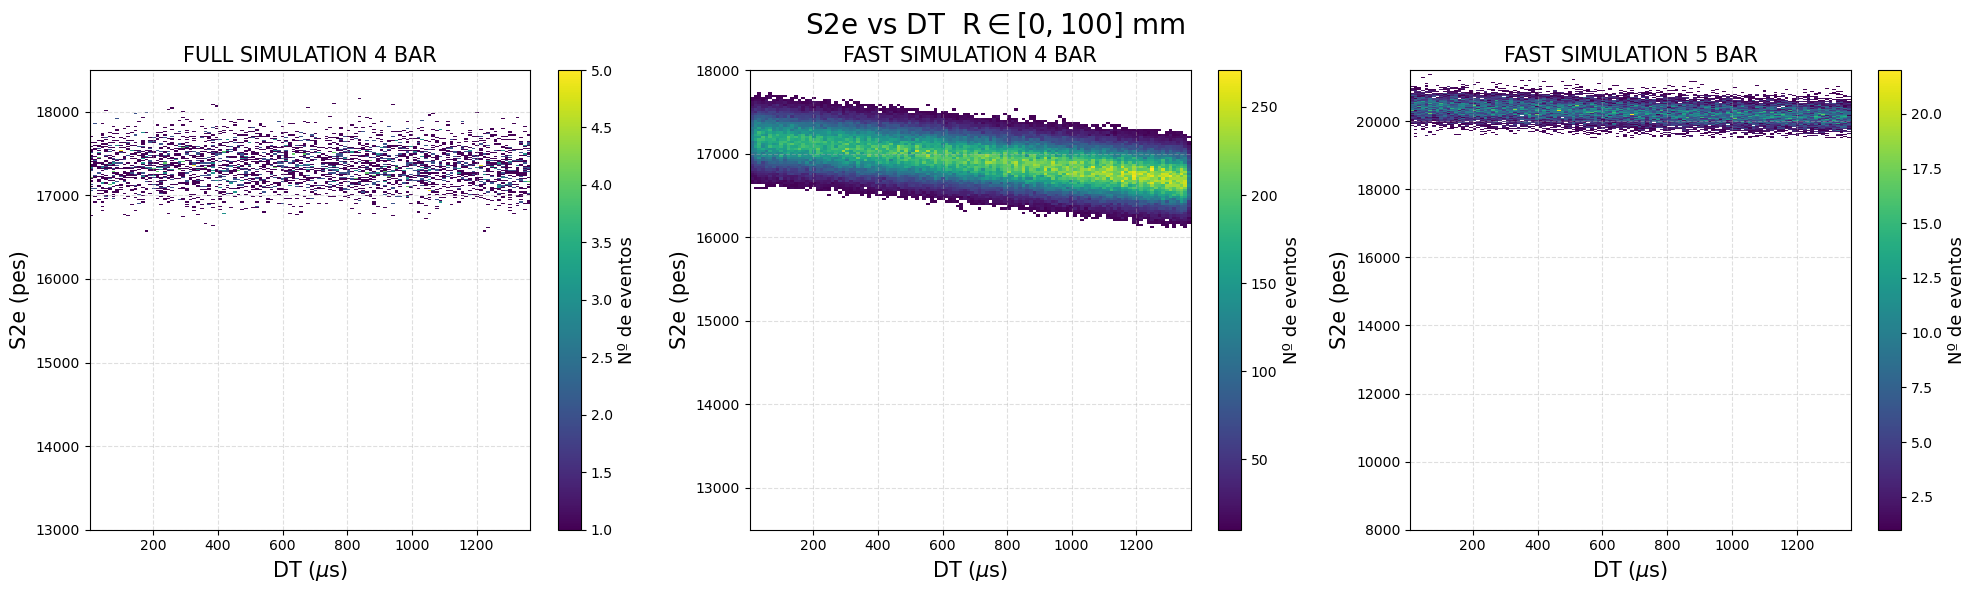

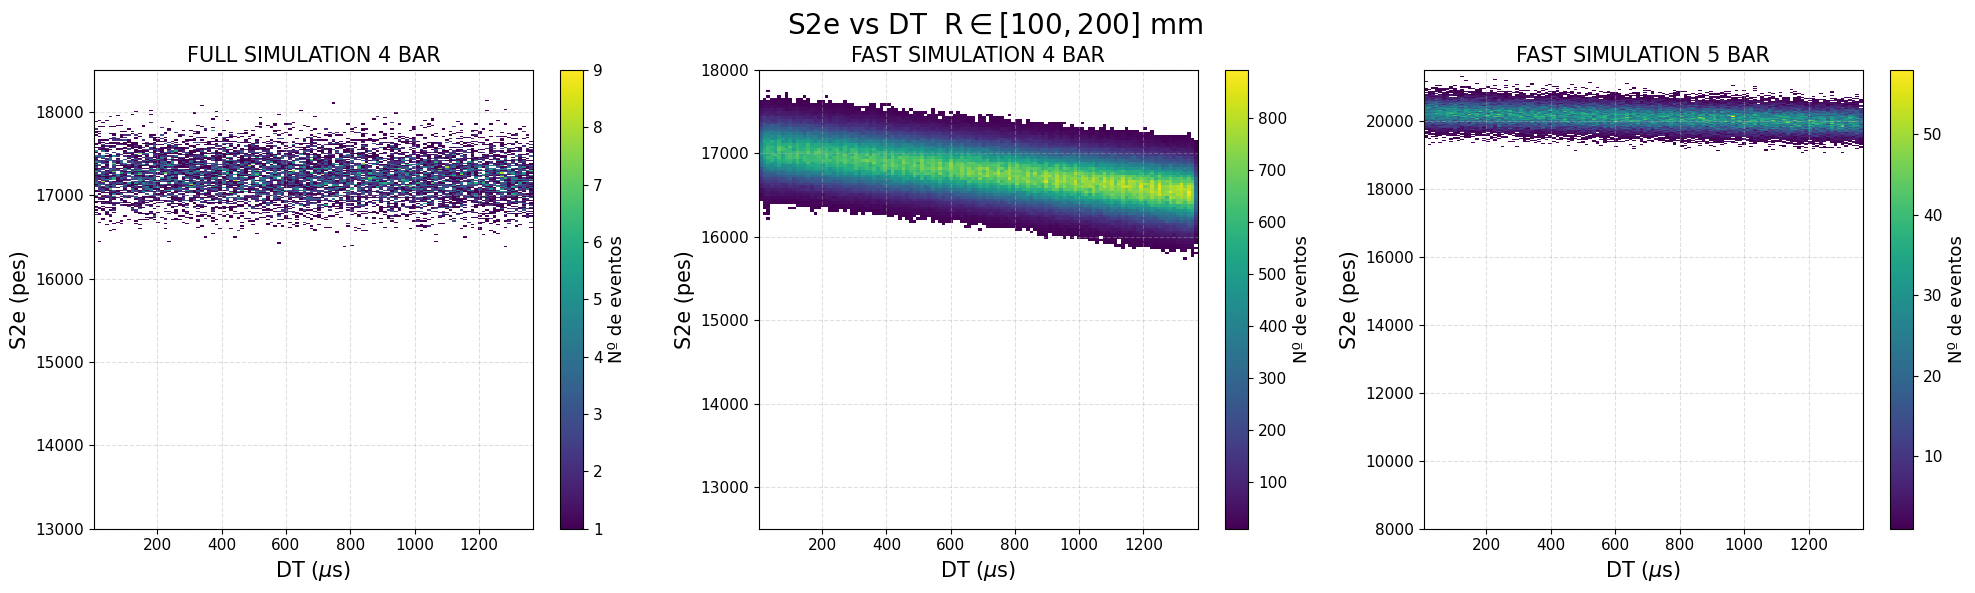

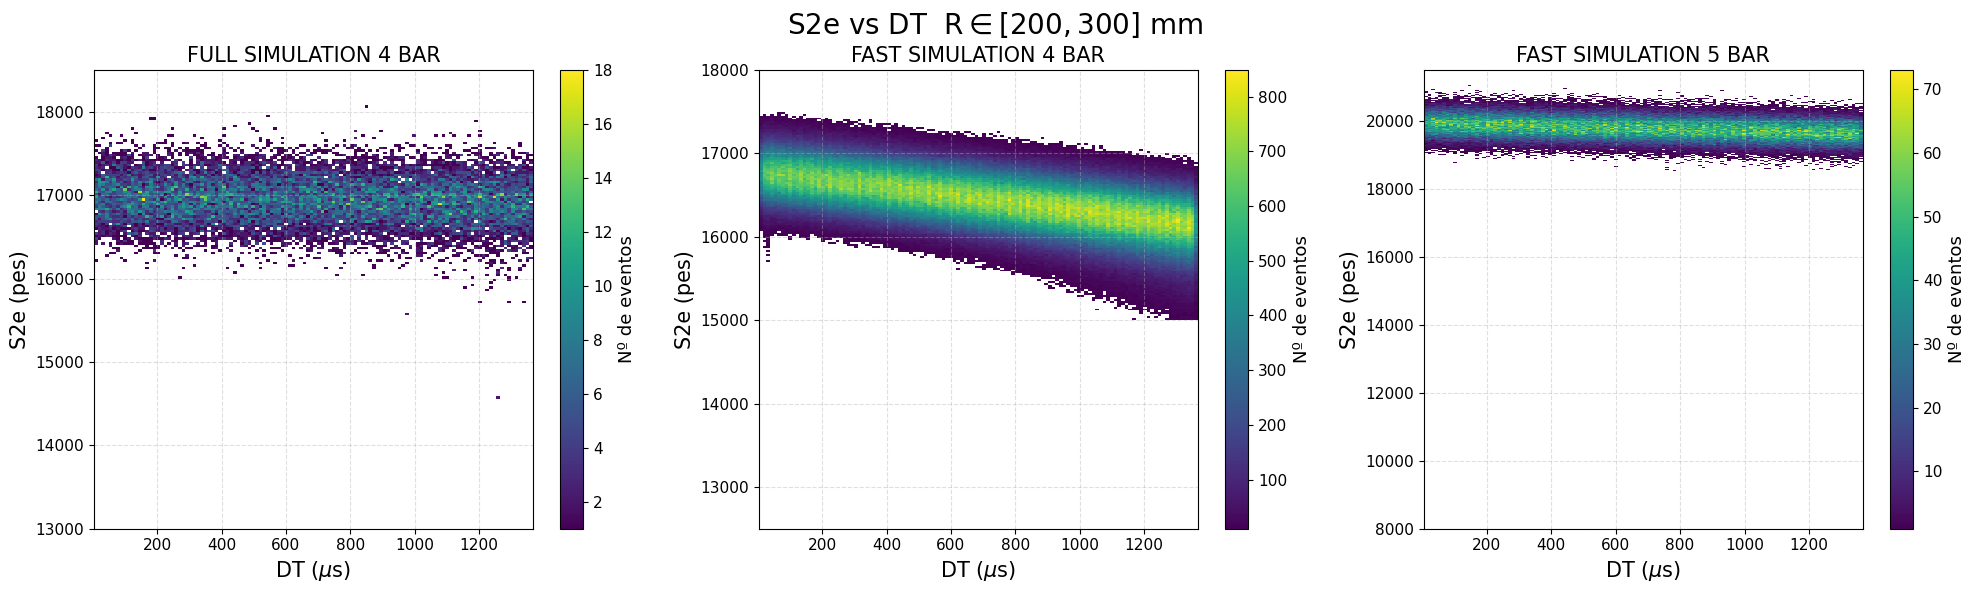

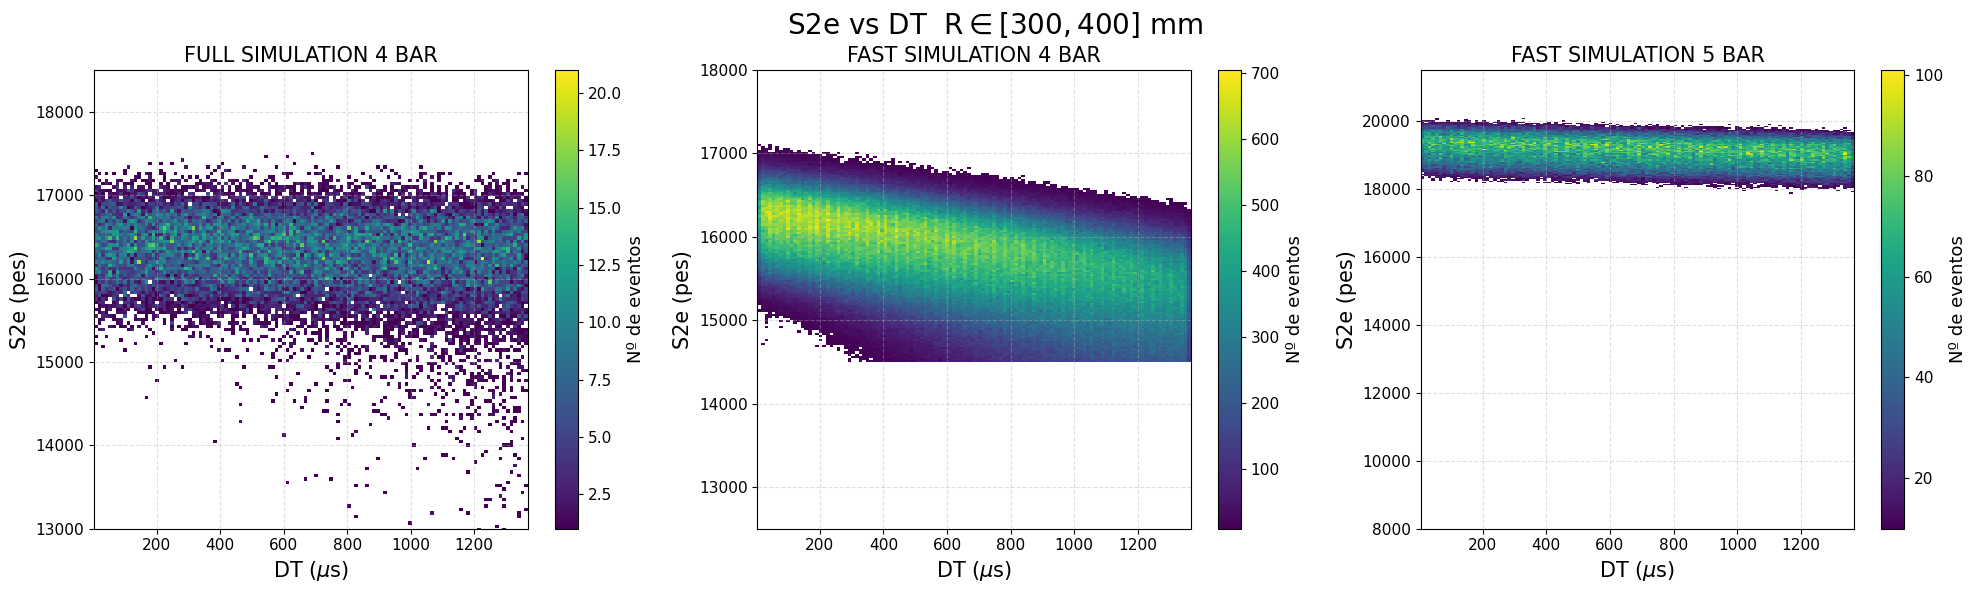

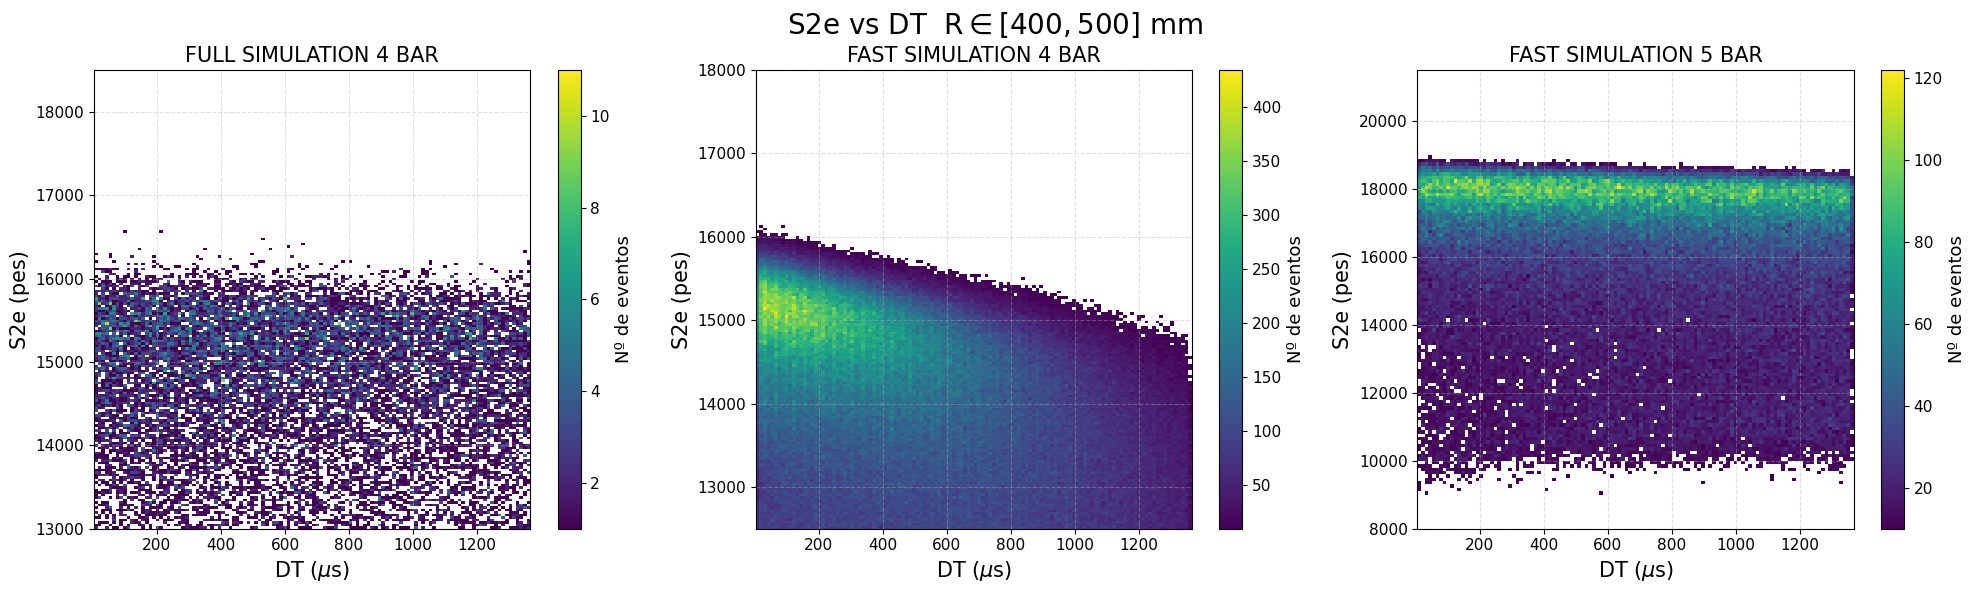

In [27]:
anillos = [(0, 100), (100, 200), (200, 300), (300, 400), (400, 500)]
simulaciones = [sim1, sim2, sim3]

# Límites del eje Y para cada anillo
ylims = {(0, 100):   [(13000, 18500), (12500, 18000), (8000, 21500)],
        (100, 200): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (200, 300): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (300, 400): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (400, 500): [(13000, 18500), (12500, 18000), (8000, 21500)]}


# Cortes de energía para cada anillo
cortes_s2e = {(0, 100):   [14700, 14700, 19500],
              (100, 200): [14400, 14000, 19000],
              (200, 300): [13700, 15000, 18500],
              (300, 400): [12600, 14500, 16500],
              (400, 500): [13000, 12500, 7500]}


cmin = {(0, 100):   [1, 10, 1],
        (100, 200): [1, 10, 1],
        (200, 300): [1, 10, 1],
        (300, 400): [1, 10, 10],
        (400, 500): [1, 10, 10],}

for r_min, r_max in anillos:            # bucle de los 5 anillos
    fig, axes = plt.subplots(1, 3, figsize = (20, 6))

    for i, ax in enumerate(axes):       # bucle de simulaciones
        sim = simulaciones[i]
        s2e_min = cortes_s2e[(r_min, r_max)][i]
        ylim = ylims[(r_min, r_max)][i]

        # Datos para el plot
        df = sim[(sim["R"] > r_min) & (sim["R"] <= r_max) & (sim["S2e"] > s2e_min)]
        DT = df["DT"]
        S2e = df["S2e"]

        # Historgrama
        h = ax.hist2d(DT, S2e, bins = 120, cmin=cmin[(r_min, r_max)][i])
        ax.set_xlabel("DT ($\\mu$s)", fontsize = 15)
        ax.set_ylabel("S2e (pes)", fontsize = 15)
        ax.set_title(titulos[i], fontsize = 15)
        ax.set_ylim(*ylim)
        ax.grid(True, linestyle = "--", alpha = 0.4)

        cbar = plt.colorbar(h[3], ax = ax)
        cbar.set_label("Nº de eventos")

    # Tamaño de ejes
    plt.rcParams["xtick.labelsize"] = 11
    plt.rcParams["ytick.labelsize"] = 11

    fig.suptitle(f"S2e vs DT  R$\\in [{r_min}, {r_max}]$ mm", fontsize = 20)
    plt.tight_layout()
    plt.subplots_adjust(top = 0.88)

In [28]:
# Guardamos gráficas individualmente por anillo
out_dir = "graficas/anillos" #directorio de las gráficas
os.makedirs(out_dir, exist_ok=True) #comprobación de su existencia, sino la crea

for r_min, r_max in anillos:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for i, ax in enumerate(axes):
        sim = simulaciones[i]
        s2e_min = cortes_s2e[(r_min, r_max)][i]
        ylim = ylims[(r_min, r_max)][i]

        df = sim[(sim.R > r_min) & (sim.R <= r_max) & (sim.S2e > s2e_min)]
        DT = df["DT"]
        S2e = df["S2e"]

        h = ax.hist2d(DT, S2e, bins = 100, cmin = 1)
        ax.set_xlabel("DT ($\\mu$s)", fontsize = 15)
        ax.set_ylabel("S2e (pes)", fontsize = 15)
        ax.set_title(titulos[i], fontsize = 15)
        ax.set_ylim(*ylim)
        ax.grid(True, linestyle = "--", alpha = 0.4)

        cbar = plt.colorbar(h[3], ax = ax)
        cbar.set_label("Nº de eventos")

    fig.suptitle(f"S2e vs DT  R$\\in [{r_min}, {r_max}]$ mm", fontsize = 20)
    plt.rcParams["xtick.labelsize"] = 12
    plt.rcParams["ytick.labelsize"] = 12
    plt.tight_layout()
    plt.subplots_adjust(top = 0.88)
    
    fname = f"S2e_vs_DT_R_{r_min:03d}-{r_max:03d}_mm.png"
    fig.savefig(os.path.join(out_dir, fname), dpi = 100)
    plt.close(fig)

## Correción de S2e por la lifetime


FULL SIMULATION 4 BAR:
  R $\in$ (0,100] mm → $\tau$ = 618039 ± 206513 $\mu$s
  R $\in$ (100,200] mm → $\tau$ = 345773 ± 39565 $\mu$s
  R $\in$ (200,300] mm → $\tau$ = 254381 ± 18576 $\mu$s
  R $\in$ (300,400] mm → $\tau$ = 81996 ± 2954 $\mu$s
  R $\in$ (400,500] mm → $\tau$ = 106669 ± 11459 $\mu$s

FAST SIMULATION 4 BAR:
  R $\in$ (0,100] mm → $\tau$ = 46106 ± 101 $\mu$s
  R $\in$ (100,200] mm → $\tau$ = 43029 ± 53 $\mu$s
  R $\in$ (200,300] mm → $\tau$ = 32425 ± 29 $\mu$s
  R $\in$ (300,400] mm → $\tau$ = 24074 ± 25 $\mu$s
  R $\in$ (400,500] mm → $\tau$ = 16093 ± 38 $\mu$s

FAST SIMULATION 5 BAR:
  R $\in$ (0,100] mm → $\tau$ = 93287 ± 1334 $\mu$s
  R $\in$ (100,200] mm → $\tau$ = 96445 ± 842 $\mu$s
  R $\in$ (200,300] mm → $\tau$ = 91559 ± 672 $\mu$s
  R $\in$ (300,400] mm → $\tau$ = 78897 ± 688 $\mu$s
  R $\in$ (400,500] mm → $\tau$ = 42949 ± 1371 $\mu$s


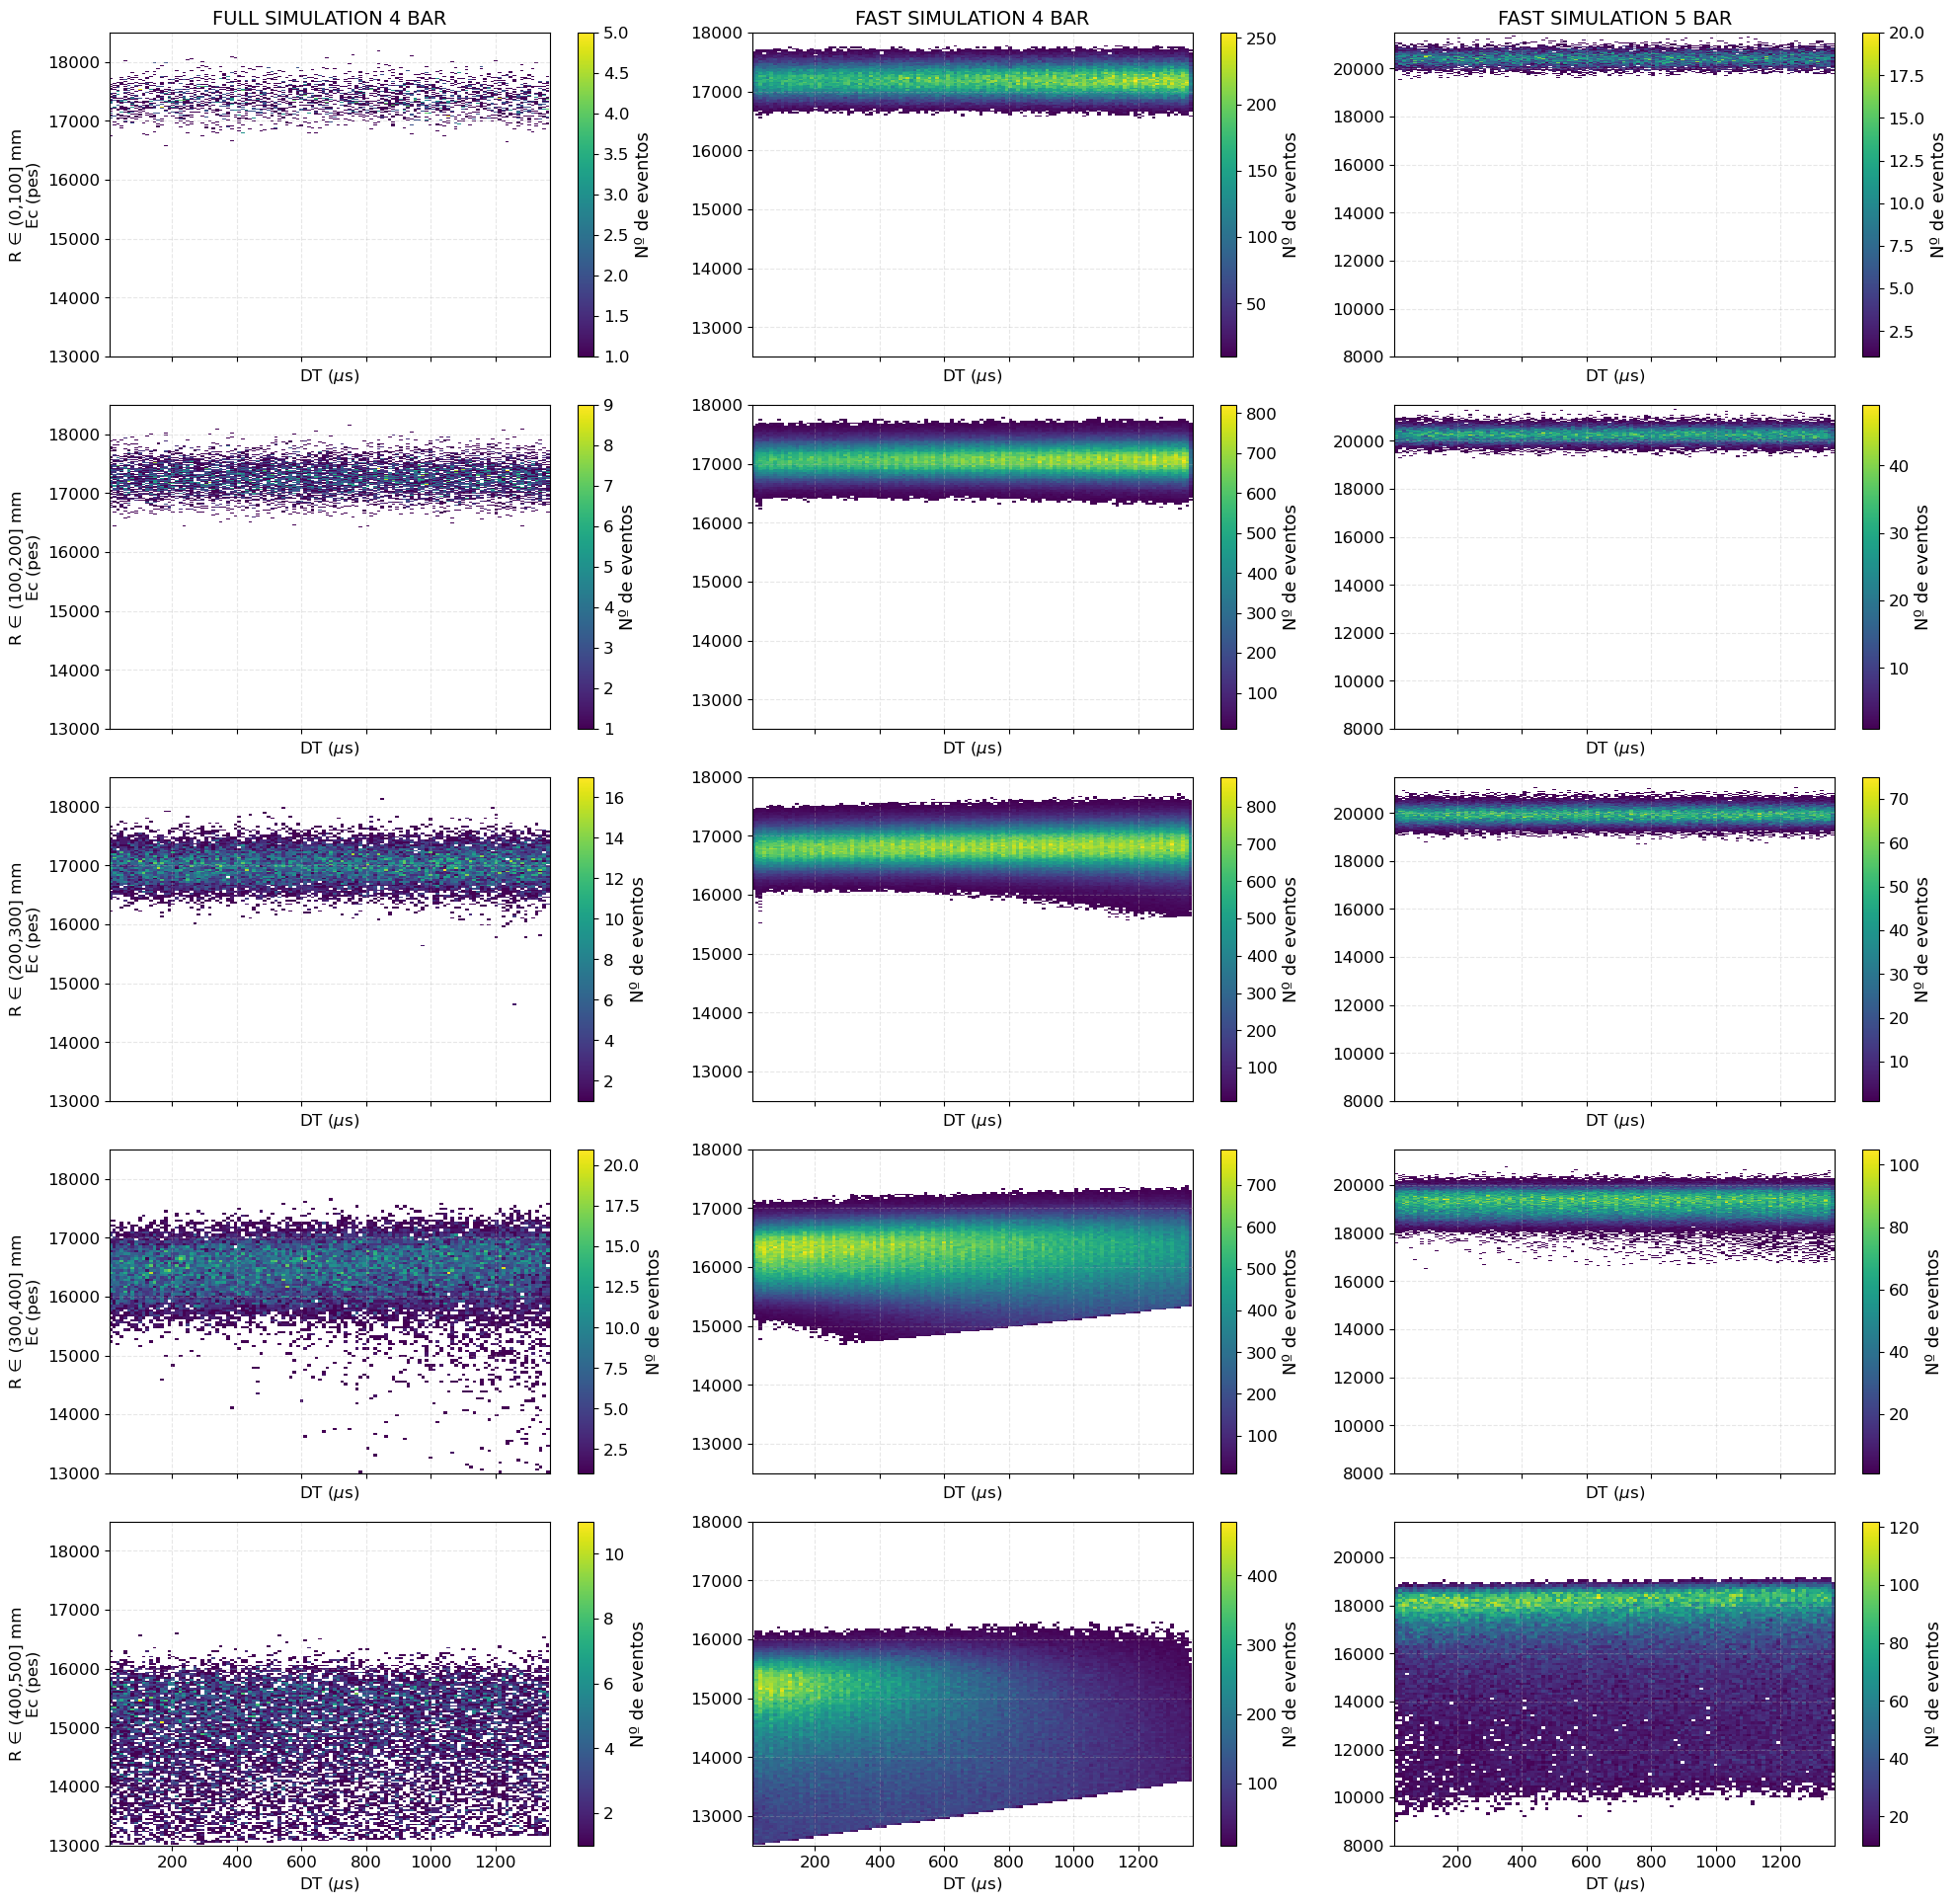

In [30]:
def modelo_exp(DT, E0, tau):
    return E0 * np.exp(-DT / tau)

ylims = {(0, 100):   [(13000, 18500), (12500, 18000), (8000, 21500)],
        (100, 200): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (200, 300): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (300, 400): [(13000, 18500), (12500, 18000), (8000, 21500)],
        (400, 500): [(13000, 18500), (12500, 18000), (8000, 21500)]}

cortes_s2e = {(0, 100):   [14700, 14700, 19500],
              (100, 200): [14400, 14000, 19000],
              (200, 300): [13700, 15000, 18500],
              (300, 400): [12600, 14500, 16500],
              (400, 500): [13000, 12500, 7500]}

cmin = {(0, 100):   [1, 10, 1],
        (100, 200): [1, 10, 1],
        (200, 300): [1, 10, 1],
        (300, 400): [1, 10, 1],
        (400, 500): [1, 10, 10]}

n_sims    = len(simulaciones)
n_anillos = len(anillos)
taus      = np.zeros((n_sims, n_anillos))
tau_errs  = np.zeros((n_sims, n_anillos))

# Creamos una variable vacía para poder guardar la Ec
Ec_all = [[None for _ in range(n_anillos)] for _ in range(n_sims)]

fig, axs = plt.subplots(n_anillos, n_sims, figsize=(20, 4 * n_anillos), sharex=True)

for i_sim, (sim, titulo) in enumerate(zip(simulaciones, titulos)):
    for j_anillo, (r_min, r_max) in enumerate(anillos):
        df = sim[(sim["R"] > r_min) & (sim["R"] <= r_max) & (sim["S2e"] > cortes_s2e[(r_min, r_max)][i_sim])]
        DT = df["DT"].values
        S2e = df["S2e"].values

        try:
            popt, pcov = curve_fit(modelo_exp, DT, S2e, p0=[np.max(S2e), 1000])
            E0, tau = popt
            tau_err = np.sqrt(np.diag(pcov))[1]
        except (RuntimeError, ValueError):
            tau, tau_err = np.nan, np.nan

        taus[i_sim, j_anillo]     = tau
        tau_errs[i_sim, j_anillo] = tau_err

        # Corrección de Ec
        Ec = S2e * np.exp(DT / tau) if not np.isnan(tau) else S2e
        Ec_all[i_sim][j_anillo] = Ec

        # Histograma 2D: DT vs Ec
        ax = axs[j_anillo, i_sim]
        h = ax.hist2d(DT, Ec, bins = 120, cmin = cmin[(r_min, r_max)][i_sim], cmap = "viridis")

        if j_anillo == 0:
            ax.set_title(titulo, fontsize = 14)
        if i_sim == 0:
            ax.set_ylabel(f"R ∈ ({r_min},{r_max}] mm\nEc (pes)", fontsize = 12)
        ax.set_xlabel("DT ($\\mu$s)", fontsize = 12)

        # Aplicar límites Y
        ylim_actual = ylims[(r_min, r_max)][i_sim]
        ax.set_ylim(*ylim_actual)

        ax.grid(True, linestyle="--", alpha=0.3)
        cbar = plt.colorbar(h[3], ax=ax)
        cbar.set_label("Nº de eventos")

plt.tight_layout()
plt.subplots_adjust(top = 0.95)

# Imprimir taus con sus errores en consola
for i, titulo in enumerate(titulos):
    print(f"\n{titulo}:")
    for j, (r_min, r_max) in enumerate(anillos):
        t   = taus[i, j]
        dt  = tau_errs[i, j]
        print(f"  R $\\in$ ({r_min},{r_max}] mm → $\\tau$ = {t:.0f} ± {dt:.0f} $\\mu$s")

In [31]:
for j_anillo, (r_min, r_max) in enumerate(anillos):
    fig, axs = plt.subplots(1, n_sims, figsize=(20, 6), sharex = True)

    for i_sim, (sim, titulo) in enumerate(zip(simulaciones, titulos)):
        df = sim[(sim["R"] > r_min) & (sim["R"] <= r_max) &
                 (sim["S2e"] > cortes_s2e[(r_min, r_max)][i_sim])]
        DT = df["DT"].values
        S2e = df["S2e"].values

        # Ajuste exponencial
        try:
            popt, pcov = curve_fit(modelo_exp, DT, S2e, p0=[np.max(S2e), 1000])
            E0, tau = popt
            tau_err = np.sqrt(np.diag(pcov))[1]
        except (RuntimeError, ValueError):
            tau, tau_err = np.nan, np.nan

        taus[i_sim, j_anillo] = tau
        tau_errs[i_sim, j_anillo] = tau_err

        Ec = S2e * np.exp(DT / tau) #if not np.isnan(tau) else S2e
        Ec_all[i_sim][j_anillo] = Ec

        ax = axs[i_sim]
        h = ax.hist2d(DT, Ec, bins = 100, cmin = cmin[(r_min, r_max)][i_sim], cmap = "viridis")
        ax.set_xlabel("DT ($\\mu$s)", fontsize = 12)
        ax.set_ylim(*ylims[(r_min, r_max)][i_sim])
        ax.grid(True, linestyle = "--", alpha = 0.4)
        cbar = plt.colorbar(h[3], ax = ax)
        cbar.set_label("Nº de eventos")
        ax.set_title(titulo, fontsize = 14)
        

    fig.suptitle(f"S2e vs DT  R$\\in [{r_min}, {r_max}]$ mm", fontsize = 20)
    plt.tight_layout()
    plt.subplots_adjust(top = 0.88)
    plt.rcParams["xtick.labelsize"] = 13
    plt.rcParams["ytick.labelsize"] = 13
    # Guardar PNG 
    fig.savefig(f"graficas/anillos_exp/Ec_vs_DT_{r_min}-{r_max}.png", dpi = 100) #seleccionamos calidad
    plt.close(fig)

## Desviación de la correción

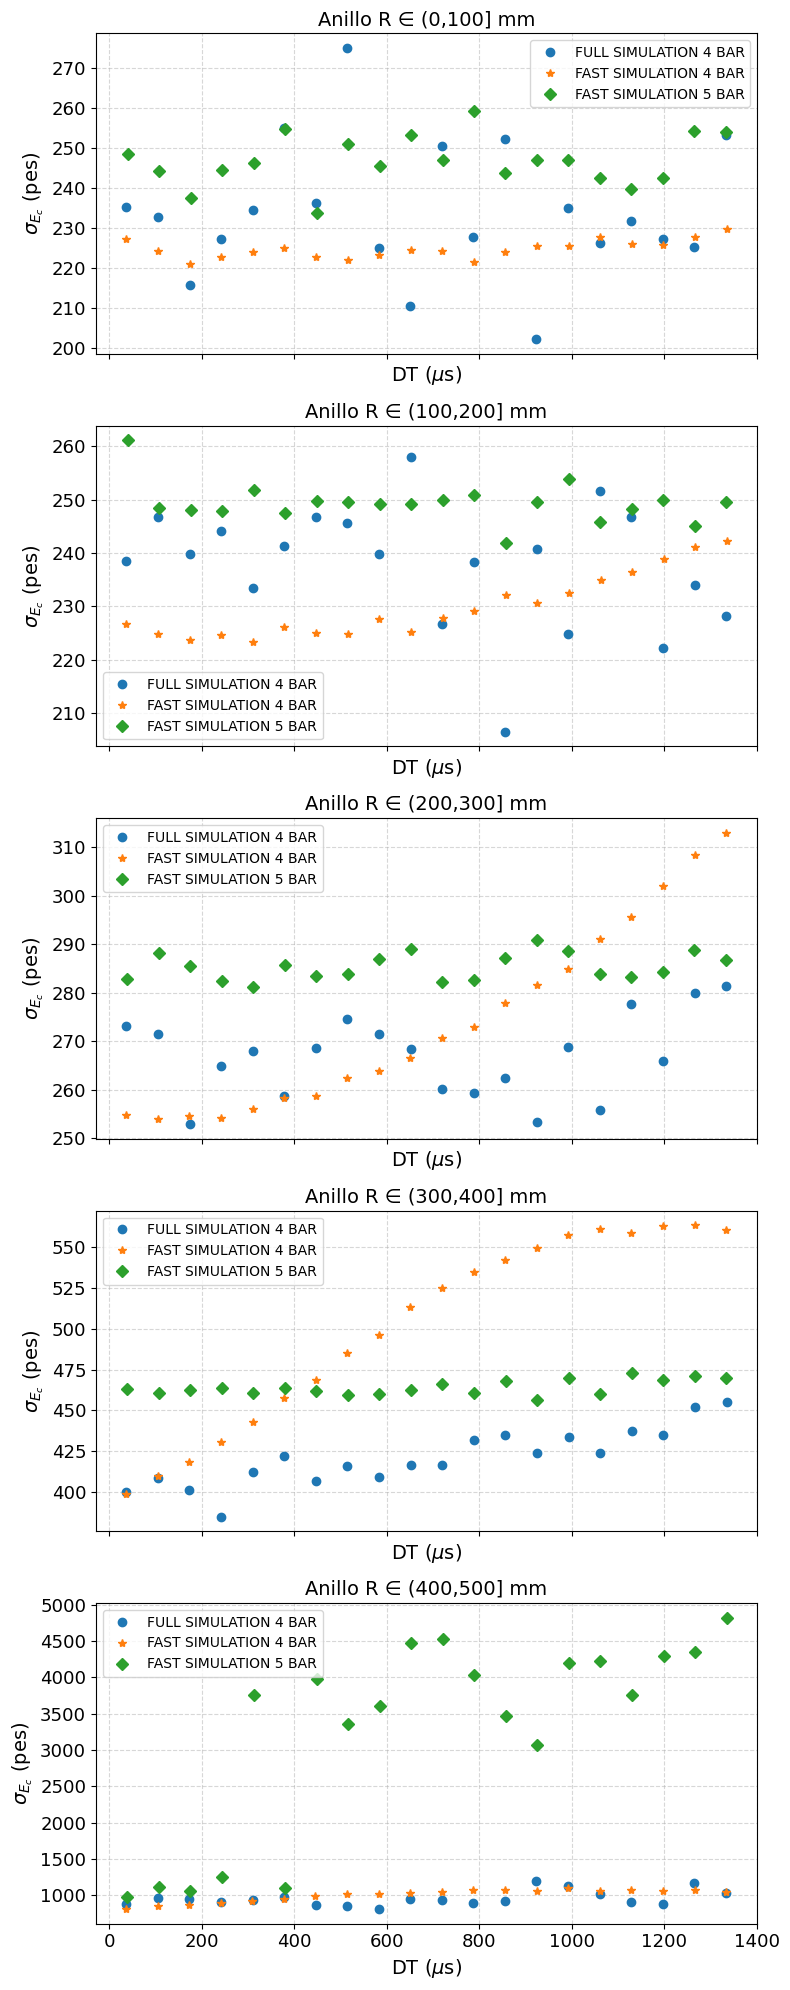

In [33]:
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

marcadores = ["o", "*", "D"]
fig, axs = plt.subplots(n_anillos, 1, figsize=(8, 4 * n_anillos), sharex=True)

for j_anillo, (r_min, r_max) in enumerate(anillos):
    ax = axs[j_anillo]
    for i_sim, (sim, titulo, marcador) in enumerate(zip(simulaciones, titulos, marcadores)):

        # FILTRADO consistente: mismo filtro que para calcular Ec_all
        mask = (sim["R"] > r_min) & (sim["R"] <= r_max) & (sim["S2e"] > cortes_s2e[(r_min, r_max)][i_sim])
        DT = sim.loc[mask, "DT"].values
        S2e = sim.loc[mask, "S2e"].values

        tau = taus[i_sim, j_anillo]

        if not np.isnan(tau):
            E_c = S2e * np.exp(DT / tau)
        else:
            E_c = S2e  # fallback si no hay tau válido

        if len(E_c) != len(DT):
            raise ValueError(f"Error: E_c tiene {len(E_c)}, pero DT tiene {len(DT)}")

        bins = np.linspace(DT.min(), DT.max(), 21)
        dt_centers = 0.5 * (bins[:-1] + bins[1:])

        sigmas = []
        for k in range(len(bins) - 1):
            bin_mask = (DT >= bins[k]) & (DT < bins[k + 1])
            if np.sum(bin_mask) < 10:
                sigmas.append(np.nan)
                continue

            delta_E = E_c[bin_mask] - np.mean(E_c[bin_mask])

            counts, edges = np.histogram(delta_E, bins=40)
            centers = 0.5 * (edges[:-1] + edges[1:])
            try:
                p0 = [counts.max(), 0, np.std(delta_E)]
                popt, _ = curve_fit(gaussiana, centers, counts, p0=p0)
                sigma = popt[2]
            except RuntimeError:
                sigma = np.nan
            sigmas.append(sigma)

        ax.plot(dt_centers, sigmas, marker=marcador, linestyle="None", label=titulo)

    ax.set_ylabel(r"$\sigma_{E_c}$ (pes)",fontsize=14)
    ax.set_xlabel(r"DT ($\mu$s)",fontsize=14)

    ax.set_title(f"Anillo R ∈ ({r_min},{r_max}] mm", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best")
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.tight_layout()

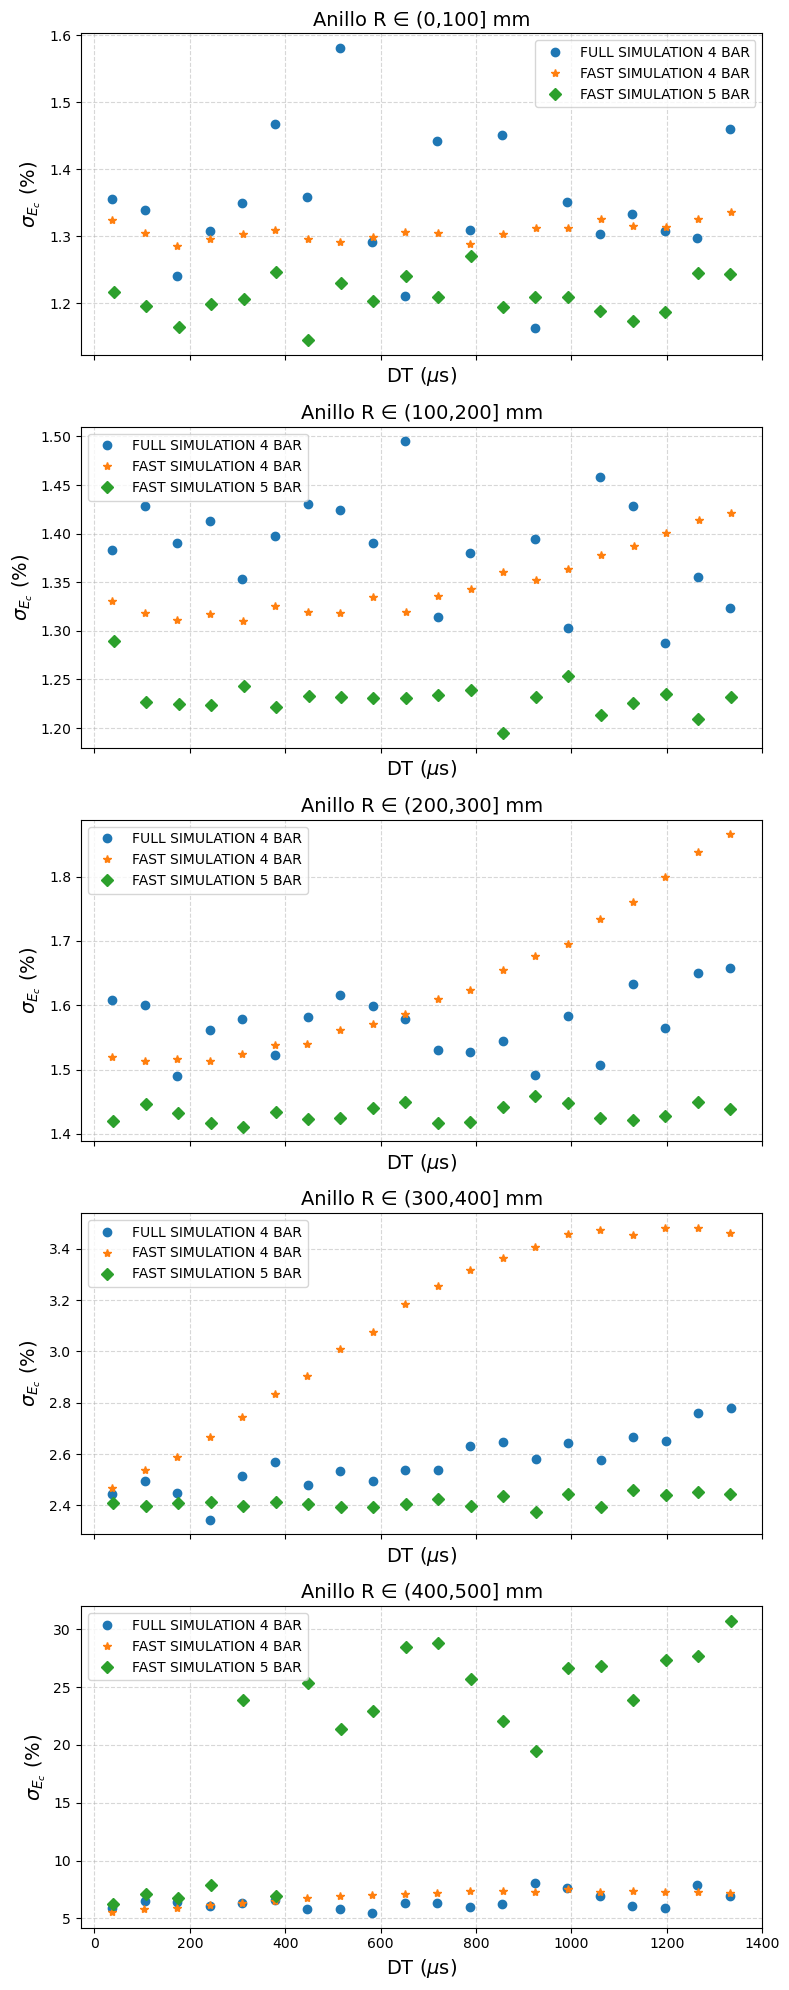

In [34]:
# Figura con un subplot por anillo para sigma en %
fig, axs = plt.subplots(n_anillos, 1, figsize=(8, 4 * n_anillos), sharex=True)

for j, (r_min, r_max) in enumerate(anillos):
    ax = axs[j]
    for i_sim, (sim, titulo, marcador) in enumerate(zip(simulaciones, titulos, marcadores)):

        # Usar exactamente el mismo filtro que para generar Ec_all
        mask = (sim["R"] > r_min) & (sim["R"] <= r_max) & (sim["S2e"] > cortes_s2e[(r_min, r_max)][i_sim])
        DT = sim.loc[mask, "DT"].values
        E_c = Ec_all[i_sim][j]  # Ya fue calculado con ese filtro en el código original

        if len(E_c) != len(DT):
            raise ValueError(f"Error: E_c tiene {len(E_c)}, pero DT tiene {len(DT)}")

        bins = np.linspace(DT.min(), DT.max(), 21)
        dt_centers = 0.5 * (bins[:-1] + bins[1:])

        sig_pct = []
        for k in range(len(bins) - 1):
            bmask = (DT >= bins[k]) & (DT < bins[k + 1])
            if np.sum(bmask) < 10:
                sig_pct.append(np.nan)
                continue

            deltaE = E_c[bmask] - np.mean(E_c[bmask])
            counts, edges = np.histogram(deltaE, bins=40)
            centers = 0.5 * (edges[:-1] + edges[1:])

            try:
                p0 = [counts.max(), 0, np.std(deltaE)]
                popt, _ = curve_fit(gaussiana, centers, counts, p0=p0)
                sigma = popt[2]
                sigma_rel = (sigma / np.mean(E_c[bmask])) * 100  # σ relativo en %
            except RuntimeError:
                sigma_rel = np.nan

            sig_pct.append(sigma_rel)

        ax.plot(dt_centers, sig_pct, marker=marcador, linestyle="None", label=titulo)

    ax.set_ylabel(r"$\sigma_{E_c}$ ($\%$)", fontsize=14)
    ax.set_xlabel(r"DT ($\mu$s)", fontsize=14)
    ax.set_title(f"Anillo R ∈ ({r_min},{r_max}] mm", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", fontsize=10)

plt.tight_layout()

In [35]:
# Bucle por anillos para guardaslas individualmente
for j, (r_min, r_max) in enumerate(anillos):
    fig, ax = plt.subplots(figsize=(8, 4))  # figura independiente por anillo

    for i_sim, (sim, titulo, marcador) in enumerate(zip(simulaciones, titulos, marcadores)):

        # Filtro consistente con el cálculo de Ec_all
        mask = (sim["R"] > r_min) & (sim["R"] <= r_max) & (sim["S2e"] > cortes_s2e[(r_min, r_max)][i_sim])
        DT = sim.loc[mask, "DT"].values
        E_c = Ec_all[i_sim][j]

        if len(E_c) != len(DT):
            raise ValueError(f"Error: E_c tiene {len(E_c)}, pero DT tiene {len(DT)}")

        # Bins de DT y centros
        bins = np.linspace(DT.min(), DT.max(), 21)
        dt_centers = 0.5 * (bins[:-1] + bins[1:])

        sig_pct = []
        for k in range(len(bins) - 1):
            bmask = (DT >= bins[k]) & (DT < bins[k + 1])
            if np.sum(bmask) < 10:
                sig_pct.append(np.nan)
                continue

            deltaE = E_c[bmask] - np.mean(E_c[bmask])
            counts, edges = np.histogram(deltaE, bins=40)
            centers = 0.5 * (edges[:-1] + edges[1:])

            try:
                p0 = [counts.max(), 0, np.std(deltaE)]
                popt, _ = curve_fit(gaussiana, centers, counts, p0=p0)
                sigma = popt[2]
                sigma_rel = (sigma / np.mean(E_c[bmask])) * 100  # en %
            except RuntimeError:
                sigma_rel = np.nan

            sig_pct.append(sigma_rel)

        ax.plot(dt_centers, sig_pct, marker=marcador, linestyle="None", label=titulo)

    # Estética del gráfico
    ax.set_ylabel(r"$\sigma_{E_c}$ ($\%$)", fontsize=14)
    ax.set_xlabel(r"DT ($\mu$s)", fontsize=14)
    ax.set_title(f"Anillo R ∈ ({r_min},{r_max}] mm", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", fontsize=10)
    ax.tick_params(labelsize=10)

    # Guardar figura
    filename = f"graficas/desviaciones/sigma_Ec_anillo_{r_min}_{r_max}.png"
    fig.tight_layout()
    fig.savefig(filename)
    plt.close(fig)
    print(f"Guardado: {filename}")

Guardado: graficas/desviaciones/sigma_Ec_anillo_0_100.png
Guardado: graficas/desviaciones/sigma_Ec_anillo_100_200.png
Guardado: graficas/desviaciones/sigma_Ec_anillo_200_300.png
Guardado: graficas/desviaciones/sigma_Ec_anillo_300_400.png
Guardado: graficas/desviaciones/sigma_Ec_anillo_400_500.png


# Toy Experiment

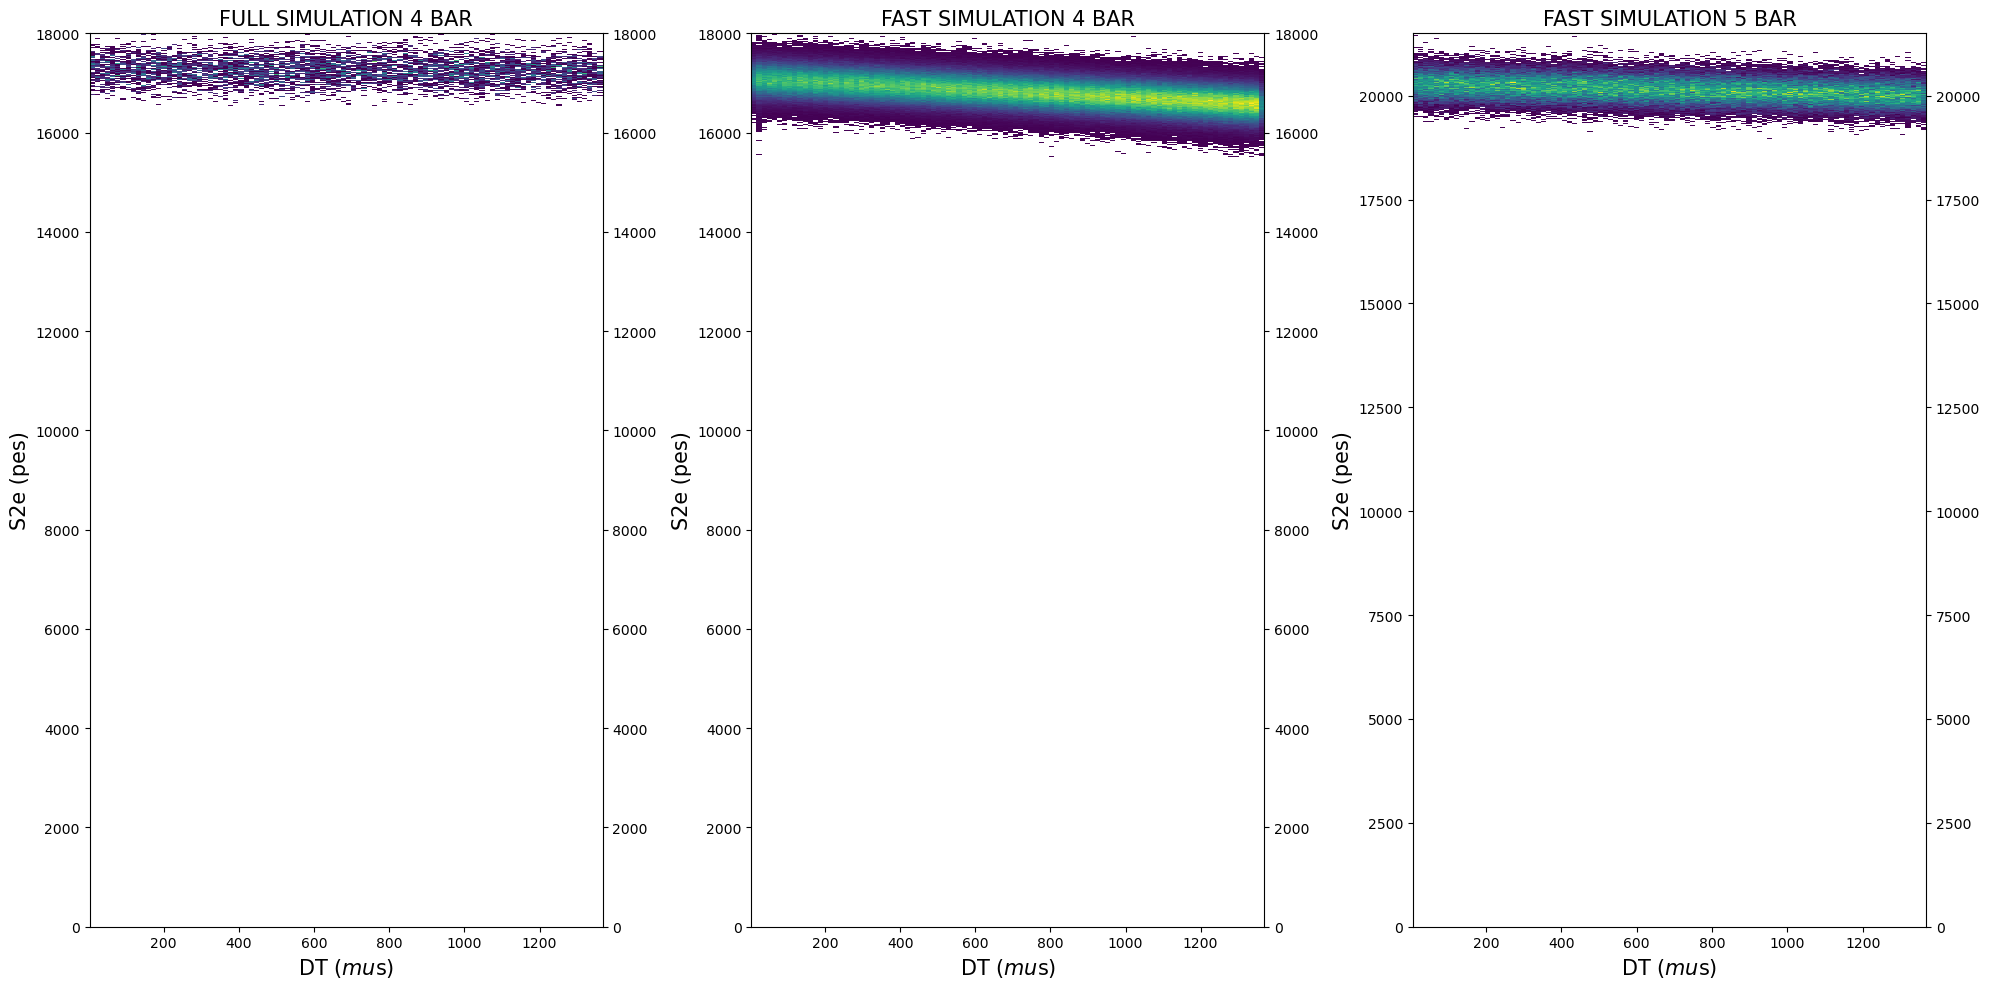

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sim1_profile300 = sim1[(sim1.R > 0) & (sim1.R <= 200)  & (sim1.S2e > 16500)]
sim2_profile300 = sim2[(sim2.R > 0) & (sim2.R <= 200)  & (sim2.S2e > 15500)]
sim3_profile300 = sim3[(sim3.R > 0) & (sim3.R <= 200)  & (sim3.S2e > 18000)]

datos = [(sim1_profile300["DT"], sim1_profile300["S2e"], (0, 18000)),
         (sim2_profile300["DT"], sim2_profile300["S2e"], (0, 18000)),
         (sim3_profile300["DT"], sim3_profile300["S2e"], (0, 21500))]

for i, ax in enumerate(axes):
    DT, S2e, ylim = datos[i]
    h = ax.hist2d(DT, S2e, bins=[100, 200], cmin=1)
    ax.set_xlabel("DT ($mu$s)", fontsize=15)
    ax.set_ylabel("S2e (pes)", fontsize=15)
    ax.set_title(titulos[i], fontsize=15)
    ax.set_ylim(*ylim)

    # Duplicar ticks y etiquetas del eje Y a la derecha
    ax.yaxis.set_ticks_position("both")
    ax.tick_params(axis="y", labelright=True)

    # cbar = plt.colorbar(h[3], ax=ax)
    # cbar.set_label("Nº de eventos")

plt.tight_layout()

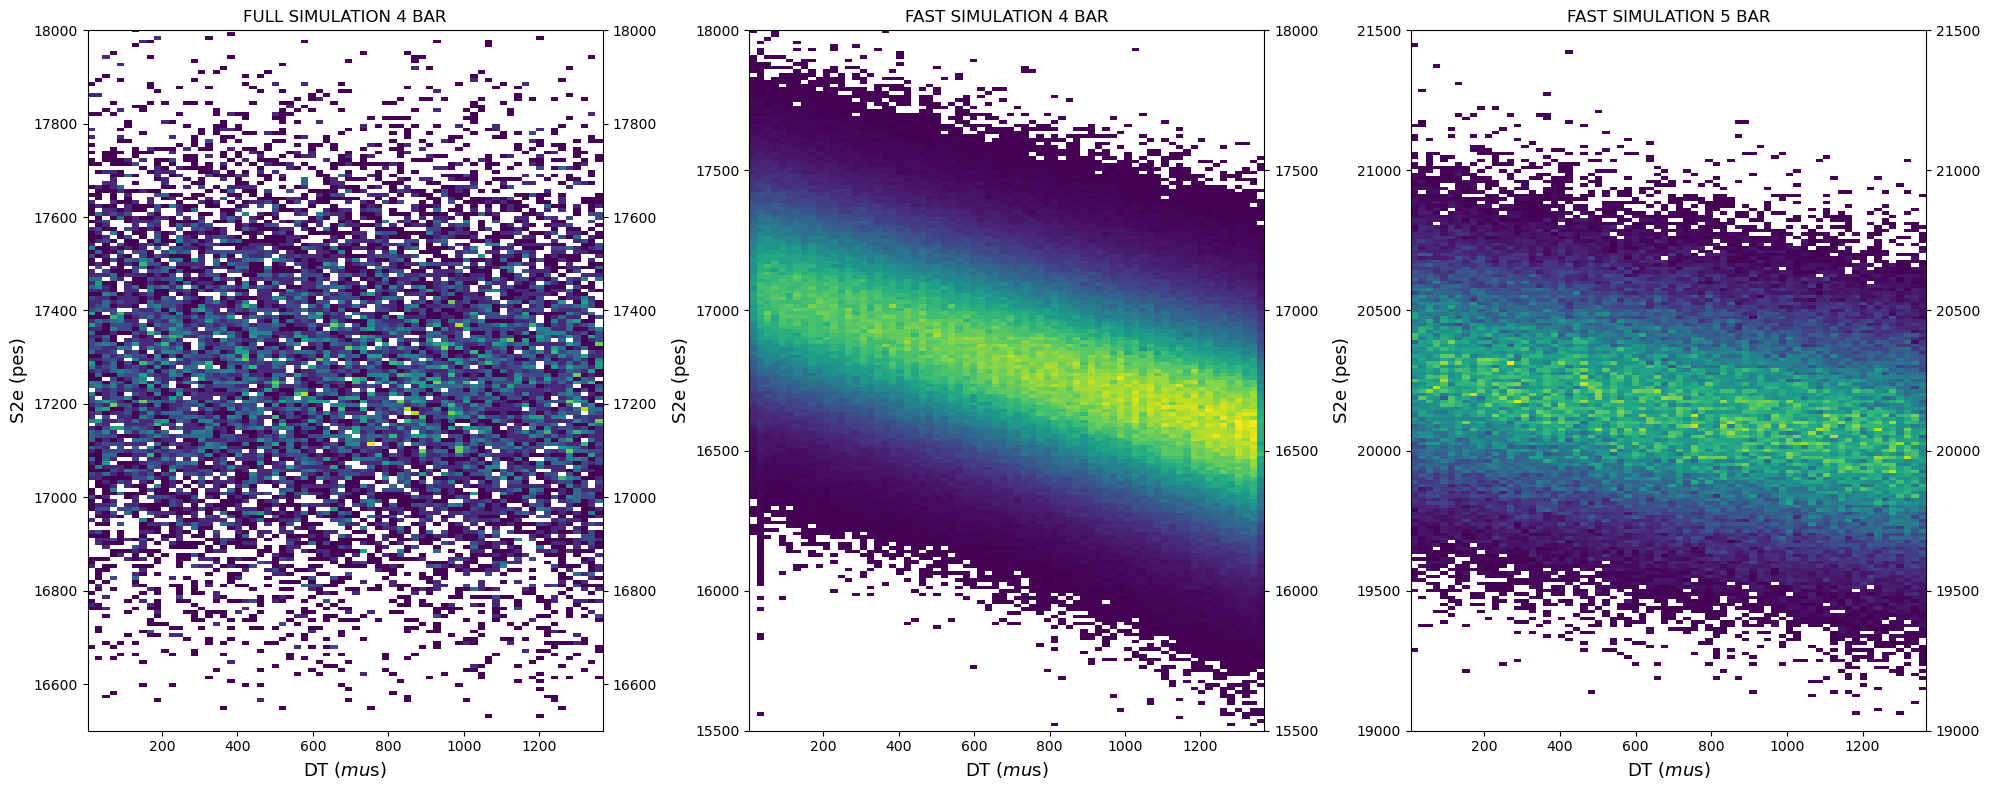

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

datos = [(sim1_profile300["DT"], sim1_profile300["S2e"], (16500, 18000)),
         (sim2_profile300["DT"], sim2_profile300["S2e"], (15500, 18000)),
         (sim3_profile300["DT"], sim3_profile300["S2e"], (19000, 21500))]
# Graficar en bucle
for i, ax in enumerate(axes):
    DT, S2e, ylim = datos[i]
    h = ax.hist2d(DT, S2e, bins=[70, 200], cmin=1)
    ax.set_xlabel("DT ($mu$s)")
    ax.set_ylabel("S2e (pes)")
    ax.set_title(titulos[i])
    ax.set_ylim(*ylim)

    ax.yaxis.set_ticks_position("both")
    ax.tick_params(axis="y", labelright=True)

plt.tight_layout()
plt.savefig("graficas/S2e zoom")

In [39]:
def plot_profile_2(DT, S2e):
    num_bins = 20
    bins = np.linspace(DT.min(), DT.max(), num_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    mean_S2e, std_S2e = [], []

    for i in range(num_bins):
        mask = (DT >= bins[i]) & (DT < bins[i + 1])
        S2e_in_bin = S2e[mask]
        
        if len(S2e_in_bin) > 0:
            mean_S2e.append(np.mean(S2e_in_bin))
            std_S2e.append(np.std(S2e_in_bin) / np.sqrt(len(S2e_in_bin)))
        else:
            mean_S2e.append(np.nan)
            std_S2e.append(np.nan)

    bin_centers = np.array(bin_centers)
    mean_S2e = np.array(mean_S2e)
    std_S2e = np.array(std_S2e)
    valid_mask = ~np.isnan(mean_S2e)

    # Ajuste exponencial
    popt, pcov = curve_fit(
        modelo_exp,
        bin_centers[valid_mask],
        mean_S2e[valid_mask],
        sigma=std_S2e[valid_mask],
        absolute_sigma=True,
        p0=[np.max(mean_S2e[valid_mask]), (DT.max() - DT.min()) / 2],
        bounds=([0, 1e-3], [np.inf, np.inf])
    )

    E0, tau = popt
    fit_line = modelo_exp(bin_centers, *popt)

    return bin_centers, mean_S2e, std_S2e, fit_line, E0, tau, pcov

Simulación 1:
    E_0  = 17289.27 ± 3.99 (pes)
    tau = 386256.77 ± 43165.87 (μs)

Simulación 2:
    E_0  = 17085.52 ± 0.35 (pes)
    tau = 43816.83 ± 49.02 (μs)

Simulación 3:
    E_0  = 20290.49 ± 1.30 (pes)
    tau = 95245.44 ± 735.83 (μs)



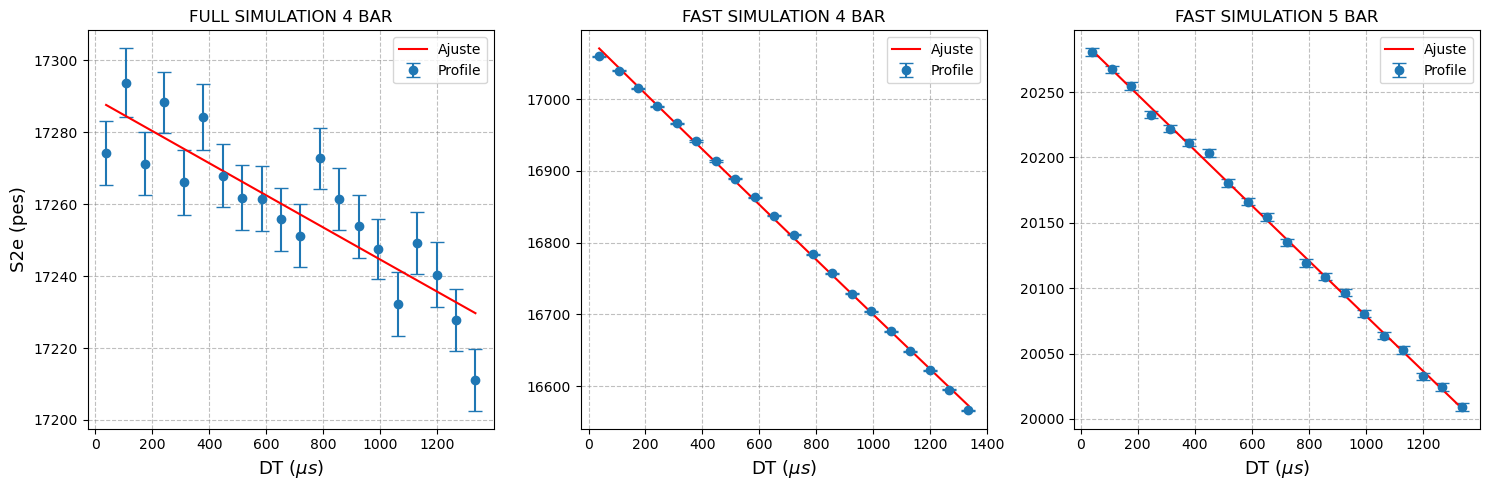

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos
datos = [sim1_profile300, sim2_profile300, sim3_profile300]

taus = []
s_taus = []
E0s = []
s_E0s = []

for i in range(3):
    sim = datos[i]
    ax = axes[i]
    
    # Perfil y ajuste exponencial
    bin_centers, mean_S2e, std_S2e, fit_line, E0, tau, pcov = plot_profile_2(sim["DT"], sim["S2e"])
    s_tau = np.sqrt(pcov[1, 1])
    s_E0 = np.sqrt(pcov[0, 0])
    
    # Guardar resultados
    E0s.append(E0)
    s_E0s.append(s_E0)
    taus.append(tau)
    s_taus.append(s_tau)

    # Resultados
    print(f"Simulación {i+1}:")
    print(f"    E_0  = {E0:.2f} ± {s_E0:.2f} (pes)")
    print(f"    tau = {tau:.2f} ± {s_tau:.2f} (μs)")
    print()

    # Graficas
    ax.errorbar(bin_centers, mean_S2e, yerr=std_S2e, fmt="o", capsize=5, label="Profile")
    ax.plot(bin_centers, fit_line, "r-", label="Ajuste")
    ax.set_title(titulos[i])
    ax.set_xlabel("DT ($\\mu s$)")
    if i == 0:
        ax.set_ylabel("S2e (pes)")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", color="gray", alpha=0.5)

plt.tight_layout()
plt.savefig("graficas/S2e_profile.png")

m = -0.00001 ± 0.0051, b = 17289.1 ± 4
m = 0.00016 ± 0.0020, b = 17085.3 ± 1.6
m = -0.00017 ± 0.0017, b = 20290.6 ± 1.4


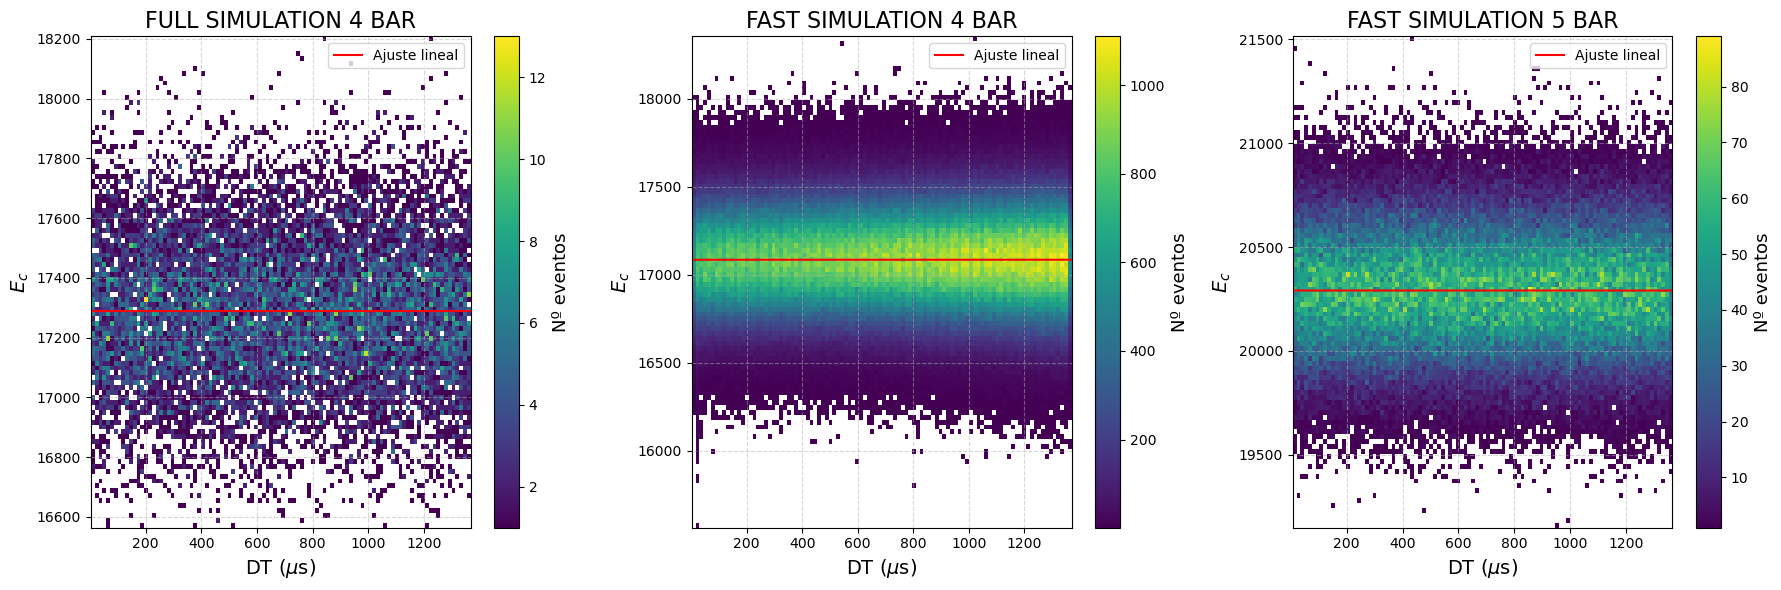

In [41]:
taus, s_taus = [], []
ms, s_ms = [], []
bs, s_bs = [], []

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (sim, titulo) in enumerate(zip(datos, titulos)):
    DT  = sim["DT"]
    S2e = sim["S2e"]
    ax  = axes[i]

    # Extraer tau del perfil de S2e
    _, _, _, _, _, tau, pcov_exp = plot_profile_2(DT, S2e)
    s_tau = np.sqrt(pcov_exp[1, 1])
    taus.append(tau)
    s_taus.append(s_tau)

    # E_c 
    Ec = S2e * np.exp(DT / tau)

    h = ax.hist2d(DT, Ec, bins=(100, 100), cmap="viridis", cmin=1)
    cb = fig.colorbar(h[3], ax=ax)
    cb.set_label("Nº eventos")

    # Perfil E_c para el ajuste lineal —
    n_bins = 30
    bins = np.linspace(DT.min(), DT.max(), n_bins + 1)
    indices = np.digitize(DT, bins) - 1
    centers = (bins[:-1] + bins[1:]) / 2

    mean_Ec  = np.full(n_bins, np.nan)
    std_Ec   = np.full(n_bins, np.nan)
    counts   = np.zeros(n_bins, dtype=int)
    for j in range(n_bins):
        mask = (indices == j)
        counts[j] = mask.sum()
        if counts[j] > 0:
            mean_Ec[j] = Ec[mask].mean()
            std_Ec[j]  = Ec[mask].std(ddof=1)

    valid = counts > 0
    x = centers[valid]
    y = mean_Ec[valid]
    sy = std_Ec[valid] / np.sqrt(counts[valid])

    # Ajuste lineal (y = m x + b)
    popt_lin, pcov_lin = np.polyfit(x, y, deg=1, cov=True)
    m, b = popt_lin
    s_m = np.sqrt(pcov_lin[0, 0])
    s_b = np.sqrt(pcov_lin[1, 1])
    ms.append(m)
    s_ms.append(s_m)
    bs.append(b)
    s_bs.append(s_b)

    line_x = np.array([DT.min(), DT.max()])
    line_y = m * line_x + b
    ax.plot(line_x, line_y, "r-", label=rf"Ajuste lineal")
    print(f"m = {m:.5f} ± {s_m:.4f}, b = {b:.6} ± {s_b:.2g}")

    ax.set_title(titulo, fontsize=16)
    ax.set_xlabel(r"DT ($\mu$s)", fontsize=14)
    ax.legend(loc="best")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.set_ylabel(r"$E_c$", fontsize=14)
    
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.tight_layout()
plt.savefig("graficas/Ec_filtrada.png", dpi=100)

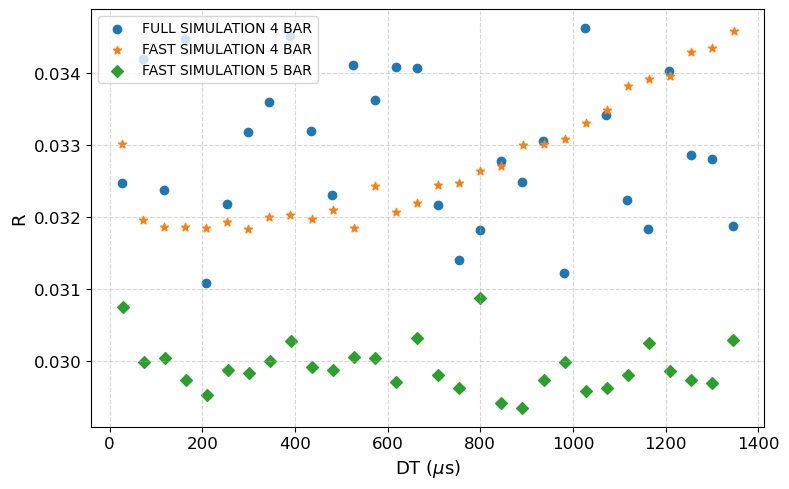

In [42]:
resoluciones_all = []  # guardamos las resoluciones para plot posterior
centers_all = []

for i, (sim, titulo) in enumerate(zip(datos, titulos)):
    DT  = sim["DT"]
    S2e = sim["S2e"]

    # Ajuste exponencial para tau
    _, _, _, _, _, tau, pcov_exp = plot_profile_2(DT, S2e)
    s_tau = np.sqrt(pcov_exp[1, 1])
    taus.append(tau)
    s_taus.append(s_tau)

    Ec = S2e * np.exp(DT / tau)

    n_bins = 30
    bins = np.linspace(DT.min(), DT.max(), n_bins + 1)
    indices = np.digitize(DT, bins) - 1
    centers = (bins[:-1] + bins[1:]) / 2

    mean_Ec = np.full(n_bins, np.nan)
    std_Ec  = np.full(n_bins, np.nan)
    counts  = np.zeros(n_bins, dtype=int)
    for j in range(n_bins):
        mask = (indices == j)
        counts[j] = mask.sum()
        if counts[j] > 0:
            mean_Ec[j] = Ec[mask].mean()
            std_Ec[j]  = Ec[mask].std(ddof=1)

    valid = counts > 0
    x = centers[valid]
    y = mean_Ec[valid]
    sy = std_Ec[valid] / np.sqrt(counts[valid])

    R = [] # Resolución
    for j in range(n_bins):
        if counts[j] > 0 and mean_Ec[j] > 0:
            r = 2*np.sqrt(2*np.log(2)) * std_Ec[j] / mean_Ec[j]
            R.append(r)
        else:
            R.append(np.nan)

    resoluciones_all.append(R)
    centers_all.append(centers)

plt.figure(figsize=(8, 5))
colores    = ["tab:blue", "tab:orange", "tab:green"]

for centers, R, marcador, color, titulo in zip(centers_all, resoluciones_all, marcadores, colores, titulos):
    plt.scatter(centers, R, marker=marcador, color=color, label=titulo)

plt.xlabel(r"DT ($\mu$s)")
plt.ylabel("R")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("graficas/resolucion")

100%|██████████| 10000/10000 [00:05<00:00, 1761.48it/s]


E0 medio: 17999.99 ± 2.22
tau medio: 50007.08 ± 431.89
E_0 = 18002.1
τ_0 = 49391 ± 424
E_1 = 17993.6
τ_1 = 51088 ± 441
E_2 = 18002.3
τ_2 = 49657 ± 415


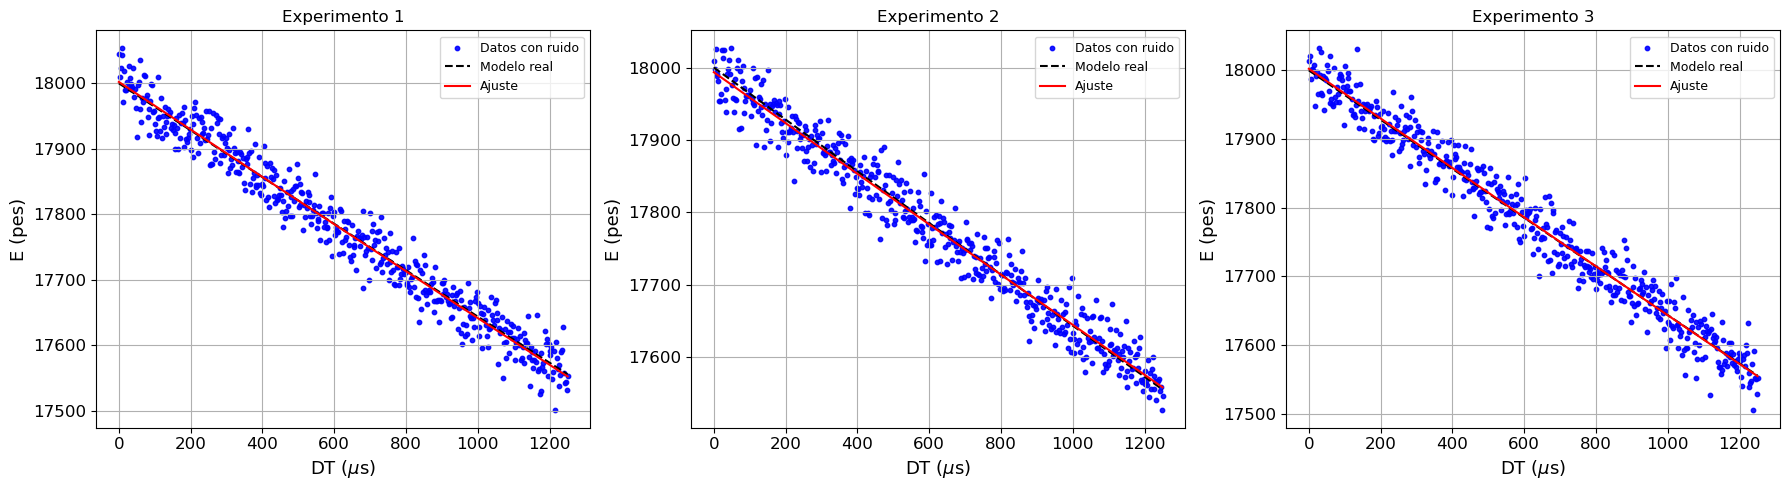

In [43]:
# Generar datos
x_datos = np.linspace(0, 1250, 500)
E0_verdadero = E0
tau_verdadero = tau

E0_verdadero = 18000
tau_verdadero = 50000

y_ideal = modelo_exp(x_datos, E0_verdadero, tau_verdadero)
size = 10000
ruido_sigma = 25

# Arreglos para guardar resultados
E0s = np.zeros(size)
taus = np.zeros(size)
s_taus = np.zeros(size)

# Guardar 3 curvas ejemplo
ejemplos_x = []
ejemplos_y = []
ejemplos_ajuste = []

np.random.seed(0)
for i in tqdm(range(size)):
    ruido = np.random.normal(0, ruido_sigma, size=x_datos.size)
    y_obs = y_ideal + ruido
    try:
        popt, pcov = curve_fit(modelo_exp, x_datos, y_obs, p0=[90, 4])
        E0s[i], taus[i] = popt
        s_taus[i] = np.sqrt(np.abs(pcov[1, 1]))  # puede que la cov. sea negativa por inestabilidad numérica
        if i < 3:
            ejemplos_x.append(x_datos.copy())
            ejemplos_y.append(y_obs.copy())
            ejemplos_ajuste.append(modelo_exp(x_datos, *popt))
    except RuntimeError:
        E0s[i], taus[i], s_taus[i] = np.nan, np.nan, np.nan

# Filtramos resultados válidos
E0s = E0s[~np.isnan(E0s)]
taus = taus[~np.isnan(taus)]

# Estadísticas
print(f"E0 medio: {np.mean(E0s):.2f} ± {np.std(E0s):.2f}")
print(f"tau medio: {np.mean(taus):.2f} ± {np.std(taus):.2f}")

# Graficar 3 casos individuales
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    axs[i].scatter(
        ejemplos_x[i],
        ejemplos_y[i],
        label="Datos con ruido",
        color="blue",
        s=10,
        alpha=0.9,
    )
    axs[i].plot(
        x_datos,
        y_ideal,
        "--",
        label="Modelo real",
        color="black",
    )
    axs[i].plot(
        x_datos,
        ejemplos_ajuste[i],
        label="Ajuste",
        color="red",
    )
    axs[i].set_title(f"Experimento {i+1}")
    axs[i].set_xlabel("DT ($\\mu$s)")
    axs[i].set_ylabel("E (pes)")
    axs[i].legend(loc="best", fontsize=9)
    axs[i].grid(True)
    print(f"E_{i} = {E0s[i]:.1f}")
    print(f"τ_{i} = {taus[i]:.0f} ± {s_taus[i]:.0f}")

plt.tight_layout()
plt.savefig("graficas/toy experiment")

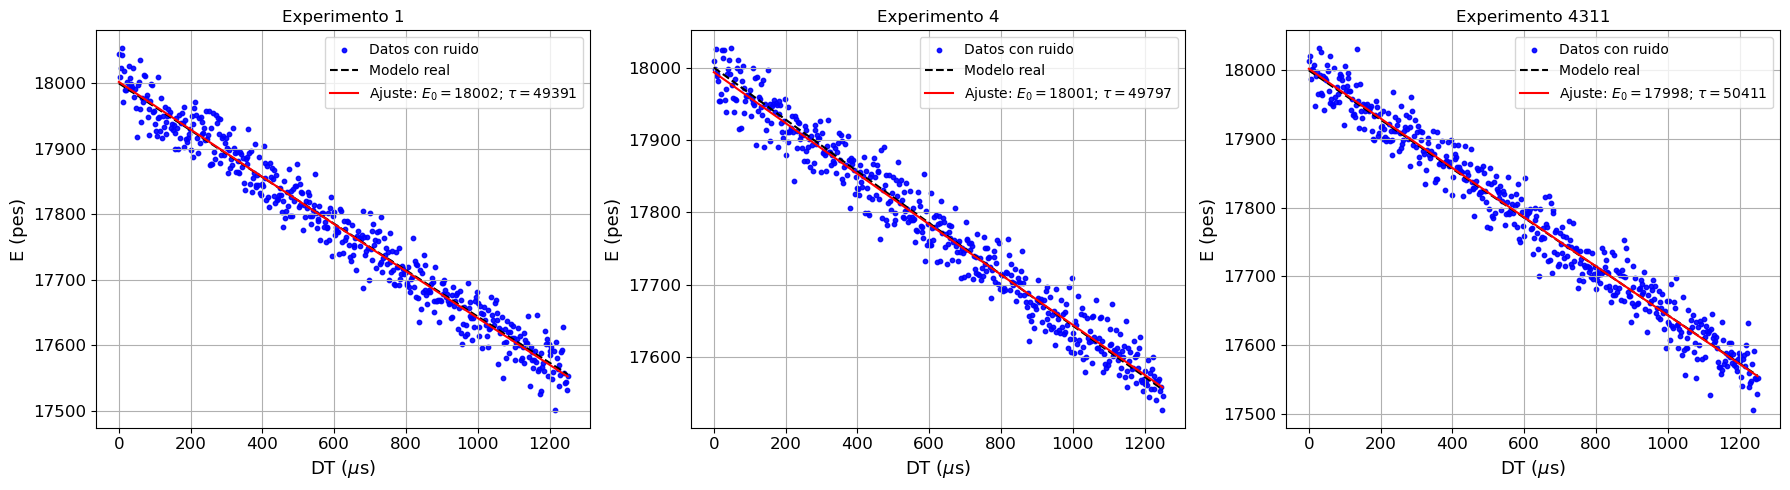

In [44]:
ejemplo_idx = [0, 3, 4310]

# Graficar los casos seleccionados
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for j in range(3):
    i_ej = ejemplo_idx[j]
    E0_val = E0s[i_ej]
    tau_val = taus[i_ej]
    s_tau_val = s_taus[i_ej]

    axs[j].scatter(ejemplos_x[j], ejemplos_y[j], label="Datos con ruido", color="blue", s=10, alpha=0.9)
    axs[j].plot(x_datos, y_ideal, "--", label="Modelo real", color="black")
    axs[j].plot(x_datos, ejemplos_ajuste[j], label = fr"Ajuste: $E_0 = {E0_val:.0f}$; $\tau = {tau_val:.0f}$", color = "red")
    axs[j].set_title(f"Experimento {i_ej + 1}")
    axs[j].set_xlabel("DT ($\\mu$s)")
    axs[j].set_ylabel("E (pes)")
    axs[j].legend(loc="best", fontsize=10)
    axs[j].grid(True)

plt.tight_layout()
plt.savefig("graficas/toy_experiment_seleccionados")

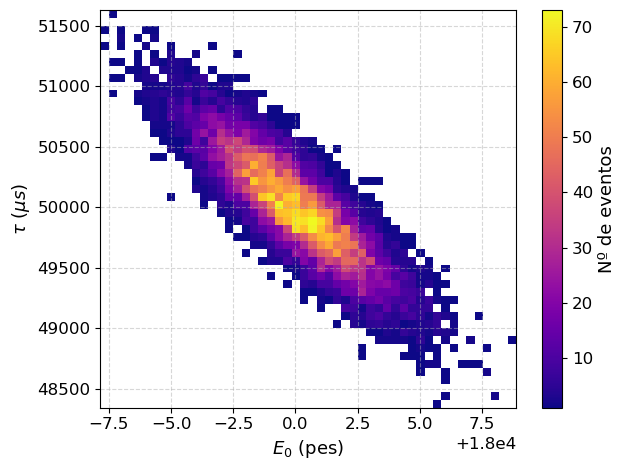

In [45]:
plt.hist2d(E0s, taus, bins=50, cmap="plasma", cmin=1)
plt.xlabel("$E_0$ (pes)")
plt.ylabel(r"$\tau \ (\mu s)$")
plt.colorbar(label="Nº de eventos")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("graficas/correlacion tau E0")

Media: -0.016650
Desviación: 0.995594


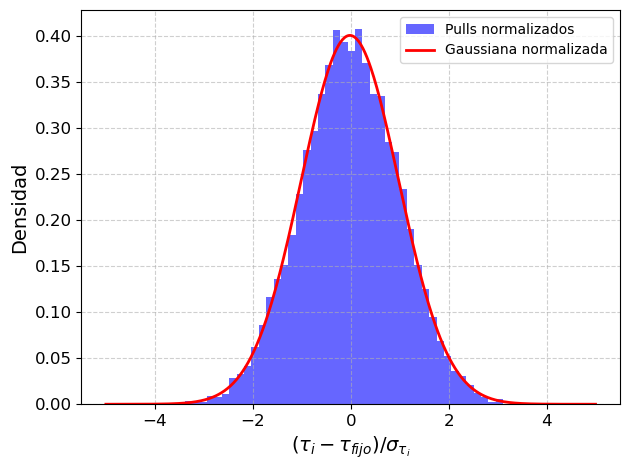

In [46]:
tau_fijo = np.mean(taus)

z = (taus - tau_fijo) / s_taus

mu_z = np.mean(z)
sigma_z = np.std(z)
print(f"Media: {mu_z:.6f}")
print(f"Desviación: {sigma_z:.6f}")

fig, ax = plt.subplots()
counts, bins, _ = ax.hist(z, bins=50, density=True, alpha=0.6, color="blue", label="Pulls normalizados")

x_vals = np.linspace(-5, 5, 500)
gauss_fit = norm.pdf(x_vals, loc=mu_z, scale=sigma_z)
ax.plot(x_vals, gauss_fit, "r-", lw=2, label=fr"Gaussiana normalizada")

ax.set_xlabel("$(\\tau_i - \\tau_{fijo})/\\sigma_{\\tau_i}$", fontsize=14)
ax.set_ylabel("Densidad", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("graficas/pull")